# بارگذاری داده‌ها

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import hashlib

COL_TABLE = "نام جدول"
COL_COLUMN = "نام ستون"
COL_DTYPE = "نوع داده"
COL_ROW_COUNT = "تعداد ردیف"
COL_MISSING_COUNT = "تعداد مقدار گمشده"
COL_MISSING_PERCENT = "درصد مقدار گمشده"

candidate_data_dirs = [
    Path("../data/dirty_data"),
    Path("data/dirty_data"),
]

data_dir = next((path for path in candidate_data_dirs if path.exists()), None)
if data_dir is None:
    raise FileNotFoundError("پوشه داده‌های خام پیدا نشد.")

csv_files = sorted(data_dir.rglob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"هیچ فایل CSV در {data_dir} پیدا نشد.")

def file_sha256(path):
    hasher = hashlib.sha256()
    with open(path, "rb") as file_obj:
        for chunk in iter(lambda: file_obj.read(1024 * 1024), b""):
            hasher.update(chunk)
    return hasher.hexdigest()

dirty_data_fingerprints_before = {
    str(path.resolve()): file_sha256(path)
    for path in sorted(data_dir.rglob("*.csv"))
}

tables = {}
for file_path in csv_files:
    tables[file_path.stem] = pd.read_csv(file_path)

if not tables:
    raise ValueError("هیچ جدولی از فایل‌های CSV خوانده نشد.")

project_root = data_dir.parent.parent.resolve()

print(f"مسیر داده‌ها: {data_dir.resolve()}")
print(f"تعداد فایل‌های CSV: {len(csv_files)}")
for table_name, df in tables.items():
    print(f"جدول {table_name}: {df.shape}")


مسیر داده‌ها: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\data\dirty_data
تعداد فایل‌های CSV: 13
جدول Categories: (9, 4)
جدول CustomerCustomerDemo: (0, 2)
جدول CustomerDemographics: (0, 2)
جدول Customers: (93, 11)
جدول Employees: (10, 18)
جدول EmployeeTerritories: (54, 2)
جدول Order_Details: (2165, 5)
جدول Orders: (835, 14)
جدول Products: (79, 10)
جدول Region: (5, 2)
جدول Shippers: (4, 3)
جدول Suppliers: (32, 12)
جدول Territories: (59, 3)


# بررسی مقادیر گمشده

In [2]:
missing_rows = []

for table_name, df in tables.items():
    total_rows = len(df)

    for column in df.columns:
        missing_count = int(df[column].isna().sum())
        missing_percent = (missing_count / total_rows) * 100 if total_rows > 0 else 0

        missing_rows.append({
            COL_TABLE: table_name,
            COL_COLUMN: column,
            COL_DTYPE: str(df[column].dtype),
            COL_ROW_COUNT: int(total_rows),
            COL_MISSING_COUNT: missing_count,
            COL_MISSING_PERCENT: float(missing_percent),
        })

missing_values_report = pd.DataFrame(missing_rows)
expected_columns = [COL_TABLE, COL_COLUMN, COL_DTYPE, COL_ROW_COUNT, COL_MISSING_COUNT, COL_MISSING_PERCENT]
missing_values_report = missing_values_report.loc[:, expected_columns]

assert not missing_values_report.empty
assert missing_values_report.shape[1] == 6
assert COL_MISSING_PERCENT in missing_values_report.columns

print(missing_values_report.shape)
print(missing_values_report.columns.tolist())
display(missing_values_report.head())
display(missing_values_report)


(88, 6)
['نام جدول', 'نام ستون', 'نوع داده', 'تعداد ردیف', 'تعداد مقدار گمشده', 'درصد مقدار گمشده']


,نام جدول,نام ستون,نوع داده,تعداد ردیف,تعداد مقدار گمشده,درصد مقدار گمشده
0,Categories,CategoryID,int64,9,0,0.000000
1,Categories,CategoryName,str,9,0,0.000000
2,Categories,Description,str,9,4,44.444444
3,Categories,Picture,str,9,0,0.000000
4,CustomerCustomerDemo,CustomerID,object,0,0,0.000000


,نام جدول,نام ستون,نوع داده,تعداد ردیف,تعداد مقدار گمشده,درصد مقدار گمشده
0,Categories,CategoryID,int64,9,0,0.000000
1,Categories,CategoryName,str,9,0,0.000000
2,Categories,Description,str,9,4,44.444444
3,Categories,Picture,str,9,0,0.000000
4,CustomerCustomerDemo,CustomerID,object,0,0,0.000000
...,...,...,...,...,...,...
83,Suppliers,Fax,str,32,22,68.750000
84,Suppliers,HomePage,str,32,0,0.000000
85,Territories,TerritoryID,int64,59,0,0.000000
86,Territories,TerritoryDescription,str,59,0,0.000000


# ستون‌های دارای Missing بالا

In [3]:
high_missing_columns = missing_values_report[
    missing_values_report[COL_MISSING_PERCENT] > 30
].copy()

if high_missing_columns.empty:
    print("ستونی با Missing بیش از ۳۰ درصد پیدا نشد.")

display(high_missing_columns)


,نام جدول,نام ستون,نوع داده,تعداد ردیف,تعداد مقدار گمشده,درصد مقدار گمشده
2,Categories,Description,str,9,4,44.444444
14,Customers,Region,str,93,61,65.591398
18,Customers,Fax,str,93,31,33.333333
28,Employees,Region,str,10,5,50.000000
55,Orders,ShipRegion,str,835,511,61.197605
62,Products,QuantityPerUnit,str,79,26,32.911392
79,Suppliers,Region,str,32,22,68.750000
83,Suppliers,Fax,str,32,22,68.750000


# مقایسه Mean و Median

In [4]:
numeric_missing_rows = []

for table_name, df in tables.items():
    numeric_columns = df.select_dtypes(include=[np.number]).columns

    for column in numeric_columns:
        missing_count = int(df[column].isna().sum())
        if missing_count == 0:
            continue

        total_rows = len(df)
        missing_percent = (missing_count / total_rows) * 100 if total_rows > 0 else 0
        mean_value = df[column].mean()
        median_value = df[column].median()

        numeric_missing_rows.append({
            COL_TABLE: table_name,
            COL_COLUMN: column,
            "تعداد Missing": missing_count,
            "درصد Missing": float(missing_percent),
            "Mean": mean_value,
            "Median": median_value,
            "اختلاف Mean و Median": abs(mean_value - median_value) if pd.notna(mean_value) and pd.notna(median_value) else np.nan,
        })

numeric_missing_summary = pd.DataFrame(numeric_missing_rows, columns=[
    COL_TABLE, COL_COLUMN, "تعداد Missing", "درصد Missing", "Mean", "Median", "اختلاف Mean و Median"
])

display(numeric_missing_summary)


,نام جدول,نام ستون,تعداد Missing,درصد Missing,Mean,Median,اختلاف Mean و Median
0,Employees,ReportsTo,1,10.000000,4.444444,2.0,2.444444
1,Order_Details,UnitPrice,6,0.277136,28.619444,18.4,10.219444
2,Order_Details,Quantity,15,0.692841,25.002791,20.0,5.002791
3,Order_Details,Discount,19,0.877598,0.058616,0.0,0.058616


# بررسی داده‌های تکراری

In [5]:
duplicate_rows = []

for table_name, df in tables.items():
    total_rows = len(df)
    duplicate_count = int(df.duplicated().sum())
    duplicate_percent = (duplicate_count / total_rows) * 100 if total_rows > 0 else 0

    duplicate_rows.append({
        COL_TABLE: table_name,
        COL_ROW_COUNT: int(total_rows),
        "تعداد ردیف تکراری": duplicate_count,
        "درصد ردیف تکراری": float(duplicate_percent),
    })

duplicate_rows_report = pd.DataFrame(duplicate_rows)
display(duplicate_rows_report)


,نام جدول,تعداد ردیف,تعداد ردیف تکراری,درصد ردیف تکراری
0,Categories,9,1,11.111111
1,CustomerCustomerDemo,0,0,0.000000
2,CustomerDemographics,0,0,0.000000
3,Customers,93,0,0.000000
4,Employees,10,0,0.000000
5,EmployeeTerritories,54,3,5.555556
6,Order_Details,2165,9,0.415704
7,Orders,835,0,0.000000
8,Products,79,1,1.265823
9,Region,5,0,0.000000


# بررسی ستون‌های متنی

In [6]:
text_whitespace_rows = []

for table_name, df in tables.items():
    text_columns = df.select_dtypes(include=["object", "string"]).columns

    for column in text_columns:
        values = df[column].dropna().astype(str)
        total_values = len(values)
        whitespace_count = int(values.ne(values.str.strip()).sum())
        whitespace_percent = (whitespace_count / total_values) * 100 if total_values > 0 else 0

        text_whitespace_rows.append({
            COL_TABLE: table_name,
            COL_COLUMN: column,
            "تعداد مقدار دارای فاصله اضافی": whitespace_count,
            "درصد مقدار دارای فاصله اضافی": float(whitespace_percent),
        })

text_whitespace_report = pd.DataFrame(text_whitespace_rows, columns=[
    COL_TABLE, COL_COLUMN,
    "تعداد مقدار دارای فاصله اضافی",
    "درصد مقدار دارای فاصله اضافی",
])

display(text_whitespace_report)


,نام جدول,نام ستون,تعداد مقدار دارای فاصله اضافی,درصد مقدار دارای فاصله اضافی
0,Categories,CategoryName,3,33.333333
1,Categories,Description,0,0.000000
2,Categories,Picture,0,0.000000
3,CustomerCustomerDemo,CustomerID,0,0.000000
4,CustomerCustomerDemo,CustomerTypeID,0,0.000000
5,CustomerDemographics,CustomerTypeID,0,0.000000
6,CustomerDemographics,CustomerDesc,0,0.000000
7,Customers,CustomerID,0,0.000000
8,Customers,CompanyName,20,21.505376
9,Customers,ContactName,15,16.129032


# بررسی جدول Order_Details

In [7]:
def normalize_table_name(name):
    return str(name).lower().replace(" ", "").replace("_", "").replace("-", "")

order_details_name = next((table_name for table_name in tables if normalize_table_name(table_name) == "orderdetails"), None)
order_details_found = order_details_name is not None

if order_details_found:
    order_details_df = tables[order_details_name]
    total_rows = len(order_details_df)
    order_quality_rows = []

    for column, check_name, condition_type in [
        ("Quantity", "Quantity <= 0", "non_positive"),
        ("UnitPrice", "UnitPrice <= 0", "non_positive"),
        ("Quantity", "Quantity Missing", "missing"),
        ("UnitPrice", "UnitPrice Missing", "missing"),
    ]:
        if column not in order_details_df.columns:
            order_quality_rows.append({"بررسی": check_name, "تعداد": np.nan, "درصد": np.nan, "پیام": f"ستون {column} پیدا نشد."})
            continue

        if condition_type == "missing":
            issue_count = int(order_details_df[column].isna().sum())
        else:
            numeric_values = pd.to_numeric(order_details_df[column], errors="coerce")
            issue_count = int((numeric_values <= 0).sum())

        issue_percent = (issue_count / total_rows) * 100 if total_rows > 0 else 0
        order_quality_rows.append({"بررسی": check_name, "تعداد": issue_count, "درصد": float(issue_percent), "پیام": f"در جدول {order_details_name} بررسی شد."})

    order_details_quality_summary = pd.DataFrame(order_quality_rows)
else:
    order_details_quality_summary = pd.DataFrame([{"پیام": "جدول Order_Details پیدا نشد."}])

display(order_details_quality_summary)


,بررسی,تعداد,درصد,پیام
0,Quantity <= 0,10,0.461894,در جدول Order_Details بررسی شد.
1,UnitPrice <= 0,6,0.277136,در جدول Order_Details بررسی شد.
2,Quantity Missing,15,0.692841,در جدول Order_Details بررسی شد.
3,UnitPrice Missing,6,0.277136,در جدول Order_Details بررسی شد.


# ذخیره گزارش‌های اولیه

In [8]:
reports_dir = project_root / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)

report_outputs = {
    "missing_values_report.csv": missing_values_report,
    "high_missing_columns.csv": high_missing_columns,
    "numeric_missing_summary.csv": numeric_missing_summary,
    "duplicate_rows_report.csv": duplicate_rows_report,
    "text_whitespace_report.csv": text_whitespace_report,
    "order_details_quality_summary.csv": order_details_quality_summary,
}

for file_name, report_df in report_outputs.items():
    report_df.to_csv(reports_dir / file_name, index=False, encoding="utf-8-sig")
    print(f"ذخیره شد: {reports_dir / file_name}")


ذخیره شد: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports\missing_values_report.csv
ذخیره شد: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports\high_missing_columns.csv
ذخیره شد: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports\numeric_missing_summary.csv
ذخیره شد: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports\duplicate_rows_report.csv
ذخیره شد: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports\text_whitespace_report.csv
ذخیره شد: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports\order_details_quality_summary.csv


# بررسی پایانی اولیه

In [9]:
total_checked_columns = int(sum(len(df.columns) for df in tables.values()))
missing_column_count = int((missing_values_report[COL_MISSING_COUNT] > 0).sum())
high_missing_count = int(len(high_missing_columns))
duplicate_table_count = int((duplicate_rows_report["تعداد ردیف تکراری"] > 0).sum())
order_details_status = "پیدا شد" if order_details_found else "پیدا نشد"

print(f"تعداد جدول‌های خوانده‌شده: {len(tables)}")
print(f"تعداد کل ستون‌های بررسی‌شده: {total_checked_columns}")
print(f"تعداد ستون‌های دارای Missing: {missing_column_count}")
print(f"تعداد ستون‌های دارای Missing بالای ۳۰ درصد: {high_missing_count}")
print(f"تعداد جدول‌های دارای Duplicate: {duplicate_table_count}")
print(f"وضعیت جدول Order_Details: {order_details_status}")
print("داده‌های اصلی تغییر داده نشده‌اند.")


تعداد جدول‌های خوانده‌شده: 13
تعداد کل ستون‌های بررسی‌شده: 88
تعداد ستون‌های دارای Missing: 23
تعداد ستون‌های دارای Missing بالای ۳۰ درصد: 8
تعداد جدول‌های دارای Duplicate: 5
وضعیت جدول Order_Details: پیدا شد
داده‌های اصلی تغییر داده نشده‌اند.


# پاکسازی داده‌ها

In [10]:
tables_clean = {
    name: df.copy()
    for name, df in tables.items()
}


# پاکسازی متن‌ها

In [11]:
text_cleaning_rows = []

for table_name, df in tables_clean.items():
    text_columns = df.select_dtypes(include=["object", "string"]).columns

    for column in text_columns:
        original_values = df[column]
        non_missing_values = original_values.dropna()
        cleaned_values = non_missing_values.astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
        changed_count = int((non_missing_values.astype(str) != cleaned_values).sum())
        df.loc[non_missing_values.index, column] = cleaned_values

        text_cleaning_rows.append({COL_TABLE: table_name, COL_COLUMN: column, "تعداد مقادیر اصلاح‌شده": changed_count})

text_cleaning_report = pd.DataFrame(text_cleaning_rows, columns=[COL_TABLE, COL_COLUMN, "تعداد مقادیر اصلاح‌شده"])
display(text_cleaning_report)


,نام جدول,نام ستون,تعداد مقادیر اصلاح‌شده
0,Categories,CategoryName,3
1,Categories,Description,0
2,Categories,Picture,2
3,CustomerCustomerDemo,CustomerID,0
4,CustomerCustomerDemo,CustomerTypeID,0
5,CustomerDemographics,CustomerTypeID,0
6,CustomerDemographics,CustomerDesc,0
7,Customers,CustomerID,0
8,Customers,CompanyName,40
9,Customers,ContactName,39


# حذف ردیف‌های کاملا تکراری

In [12]:
duplicate_removal_rows = []

for table_name, df in tables_clean.items():
    rows_before = int(len(df))
    tables_clean[table_name] = df.drop_duplicates().reset_index(drop=True)
    rows_after = int(len(tables_clean[table_name]))
    removed_rows = rows_before - rows_after
    duplicate_removal_rows.append({"نام جدول": table_name, "تعداد ردیف قبل": rows_before, "تعداد ردیف بعد": rows_after, "تعداد ردیف حذف‌شده": removed_rows})

duplicate_removal_report = pd.DataFrame(duplicate_removal_rows)
display(duplicate_removal_report)

PRIMARY_KEY_MAP = {
    "Customers": "CustomerID",
    "Orders": "OrderID",
    "Products": "ProductID",
    "Employees": "EmployeeID",
    "Suppliers": "SupplierID",
    "Categories": "CategoryID",
    "Shippers": "ShipperID",
    "Region": "RegionID",
    "Territories": "TerritoryID",
}

primary_key_cleaning_rows = []

for expected_table, key_col in PRIMARY_KEY_MAP.items():
    actual_table = next((name for name in tables_clean if normalize_table_name(name) == normalize_table_name(expected_table)), None)
    if actual_table is None:
        primary_key_cleaning_rows.append({
            "نام جدول": expected_table,
            "نام کلید اصلی": key_col,
            "تعداد ردیف قبل": 0,
            "تعداد کلیدهای تکراری قبل": 0,
            "تعداد ردیف حذف‌شده": 0,
            "تعداد ردیف بعد": 0,
            "تعداد کلیدهای تکراری بعد": 0,
            "روش اصلاح": "جدول پیدا نشد.",
        })
        continue

    df = tables_clean[actual_table].copy()
    rows_before = int(len(df))
    if key_col not in df.columns:
        primary_key_cleaning_rows.append({
            "نام جدول": actual_table,
            "نام کلید اصلی": key_col,
            "تعداد ردیف قبل": rows_before,
            "تعداد کلیدهای تکراری قبل": 0,
            "تعداد ردیف حذف‌شده": 0,
            "تعداد ردیف بعد": rows_before,
            "تعداد کلیدهای تکراری بعد": 0,
            "روش اصلاح": "ستون کلید اصلی پیدا نشد.",
        })
        continue

    duplicate_keys_before = int(df.loc[df[key_col].notna() & df[key_col].duplicated(keep=False), key_col].nunique())
    missing_key_mask = df[key_col].isna()
    missing_key_count = int(missing_key_mask.sum())

    working = df.loc[~missing_key_mask].copy()
    working["__original_order__"] = np.arange(len(working))
    working["__missing_count__"] = working.isna().sum(axis=1)
    working = working.sort_values([key_col, "__missing_count__", "__original_order__"], kind="mergesort")
    cleaned = working.drop_duplicates(subset=[key_col], keep="first").sort_values("__original_order__", kind="mergesort")
    cleaned = cleaned.drop(columns=["__original_order__", "__missing_count__"]).reset_index(drop=True)

    rows_after = int(len(cleaned))
    duplicate_keys_after = int(cleaned.loc[cleaned[key_col].notna() & cleaned[key_col].duplicated(keep=False), key_col].nunique())
    removed_rows = rows_before - rows_after

    method_parts = []
    if missing_key_count:
        method_parts.append(f"حذف {missing_key_count} ردیف با کلید اصلی خالی")
    if duplicate_keys_before:
        method_parts.append("برای کلیدهای تکراری، ردیف با Missing کمتر نگه داشته شد؛ در تساوی اولین ردیف حفظ شد")
    if not method_parts:
        method_parts.append("نیاز به اصلاح نداشت")

    tables_clean[actual_table] = cleaned
    primary_key_cleaning_rows.append({
        "نام جدول": actual_table,
        "نام کلید اصلی": key_col,
        "تعداد ردیف قبل": rows_before,
        "تعداد کلیدهای تکراری قبل": duplicate_keys_before,
        "تعداد ردیف حذف‌شده": removed_rows,
        "تعداد ردیف بعد": rows_after,
        "تعداد کلیدهای تکراری بعد": duplicate_keys_after,
        "روش اصلاح": "؛ ".join(method_parts),
    })

primary_key_cleaning_report = pd.DataFrame(primary_key_cleaning_rows, columns=[
    "نام جدول",
    "نام کلید اصلی",
    "تعداد ردیف قبل",
    "تعداد کلیدهای تکراری قبل",
    "تعداد ردیف حذف‌شده",
    "تعداد ردیف بعد",
    "تعداد کلیدهای تکراری بعد",
    "روش اصلاح",
])
display(primary_key_cleaning_report)


,نام جدول,تعداد ردیف قبل,تعداد ردیف بعد,تعداد ردیف حذف‌شده
0,Categories,9,8,1
1,CustomerCustomerDemo,0,0,0
2,CustomerDemographics,0,0,0
3,Customers,93,93,0
4,Employees,10,10,0
5,EmployeeTerritories,54,51,3
6,Order_Details,2165,2156,9
7,Orders,835,835,0
8,Products,79,78,1
9,Region,5,4,1


,نام جدول,نام کلید اصلی,تعداد ردیف قبل,تعداد کلیدهای تکراری قبل,تعداد ردیف حذف‌شده,تعداد ردیف بعد,تعداد کلیدهای تکراری بعد,روش اصلاح
0,Customers,CustomerID,93,2,2,91,0,برای کلیدهای تکراری، ردیف با Missing کمتر نگه ...
1,Orders,OrderID,835,5,5,830,0,برای کلیدهای تکراری، ردیف با Missing کمتر نگه ...
2,Products,ProductID,78,1,1,77,0,برای کلیدهای تکراری، ردیف با Missing کمتر نگه ...
3,Employees,EmployeeID,10,0,0,10,0,نیاز به اصلاح نداشت
4,Suppliers,SupplierID,31,2,2,29,0,برای کلیدهای تکراری، ردیف با Missing کمتر نگه ...
5,Categories,CategoryID,8,0,0,8,0,نیاز به اصلاح نداشت
6,Shippers,ShipperID,3,0,0,3,0,نیاز به اصلاح نداشت
7,Region,RegionID,4,0,0,4,0,نیاز به اصلاح نداشت
8,Territories,TerritoryID,57,2,2,55,0,برای کلیدهای تکراری، ردیف با Missing کمتر نگه ...


# جایگزینی مقادیر گمشده

In [13]:
missing_imputation_rows = []

for table_name, df in tables_clean.items():
    total_rows = len(df)

    for column in df.columns:
        missing_before = int(df[column].isna().sum())
        if missing_before == 0:
            continue

        missing_percent_before = (missing_before / total_rows) * 100 if total_rows > 0 else 0
        dtype_before = str(df[column].dtype)

        if "discount" in str(column).lower():
            df[column] = df[column].fillna(0)
            method = "جایگزینی با صفر"
        elif pd.api.types.is_numeric_dtype(df[column]):
            mean_value = df[column].mean()
            median_value = df[column].median()
            fill_value = median_value if pd.notna(median_value) else mean_value
            df[column] = df[column].fillna(fill_value)
            method = f"جایگزینی با میانه: {median_value}"
        else:
            df[column] = df[column].fillna("Unknown")
            method = "جایگزینی با Unknown"

        missing_after = int(df[column].isna().sum())
        missing_imputation_rows.append({
            COL_TABLE: table_name,
            COL_COLUMN: column,
            COL_DTYPE: dtype_before,
            "تعداد Missing قبل": missing_before,
            "درصد Missing قبل": float(missing_percent_before),
            "روش جایگزینی": method,
            "تعداد Missing بعد": missing_after,
        })

missing_imputation_report = pd.DataFrame(missing_imputation_rows, columns=[COL_TABLE, COL_COLUMN, COL_DTYPE, "تعداد Missing قبل", "درصد Missing قبل", "روش جایگزینی", "تعداد Missing بعد"])
display(missing_imputation_report)


,نام جدول,نام ستون,نوع داده,تعداد Missing قبل,درصد Missing قبل,روش جایگزینی,تعداد Missing بعد
0,Categories,Description,str,4,50.000000,جایگزینی با Unknown,0
1,Customers,ContactTitle,str,4,4.395604,جایگزینی با Unknown,0
2,Customers,Region,str,60,65.934066,جایگزینی با Unknown,0
3,Customers,PostalCode,str,11,12.087912,جایگزینی با Unknown,0
4,Customers,Fax,str,30,32.967033,جایگزینی با Unknown,0
5,Employees,FirstName,str,1,10.000000,جایگزینی با Unknown,0
6,Employees,TitleOfCourtesy,str,2,20.000000,جایگزینی با Unknown,0
7,Employees,Region,str,5,50.000000,جایگزینی با Unknown,0
8,Employees,Photo,str,1,10.000000,جایگزینی با Unknown,0
9,Employees,Notes,str,3,30.000000,جایگزینی با Unknown,0


# اصلاح جدول Order_Details

In [14]:
order_details_cleaning_rows = []
order_details_cleaned_name = next((table_name for table_name in tables_clean if normalize_table_name(table_name) == "orderdetails"), None)

if order_details_cleaned_name is not None:
    order_details_clean = tables_clean[order_details_cleaned_name]

    if "Discount" in order_details_clean.columns:
        discount_missing_before = int(order_details_clean["Discount"].isna().sum())
        order_details_clean["Discount"] = order_details_clean["Discount"].fillna(0)
        order_details_cleaning_rows.append({"نوع مشکل": "مقدار گمشده Discount", "تعداد قبل": discount_missing_before, "اقدام انجام‌شده": "جایگزینی با صفر", "تعداد بعد": int(order_details_clean["Discount"].isna().sum())})

        discount_below_before = int((order_details_clean["Discount"] < 0).sum())
        order_details_clean.loc[order_details_clean["Discount"] < 0, "Discount"] = 0
        order_details_cleaning_rows.append({"نوع مشکل": "کمتر از صفر Discount", "تعداد قبل": discount_below_before, "اقدام انجام‌شده": "تنظیم روی صفر", "تعداد بعد": int((order_details_clean["Discount"] < 0).sum())})

        discount_above_before = int((order_details_clean["Discount"] > 1).sum())
        order_details_clean.loc[order_details_clean["Discount"] > 1, "Discount"] = 1
        order_details_cleaning_rows.append({"نوع مشکل": "بیشتر از یک Discount", "تعداد قبل": discount_above_before, "اقدام انجام‌شده": "تنظیم روی یک", "تعداد بعد": int((order_details_clean["Discount"] > 1).sum())})

    if "Quantity" in order_details_clean.columns:
        quantity_values = pd.to_numeric(order_details_clean["Quantity"], errors="coerce")
        quantity_before = int(quantity_values.isna().sum() + (quantity_values <= 0).sum())
        order_details_clean = order_details_clean[quantity_values > 0].copy()
        order_details_cleaning_rows.append({"نوع مشکل": "Quantity نامعتبر یا خالی", "تعداد قبل": quantity_before, "اقدام انجام‌شده": "حذف ردیف", "تعداد بعد": int((pd.to_numeric(order_details_clean["Quantity"], errors="coerce") <= 0).sum())})

    if "UnitPrice" in order_details_clean.columns:
        unit_price_values = pd.to_numeric(order_details_clean["UnitPrice"], errors="coerce")
        unit_price_before = int(unit_price_values.isna().sum() + (unit_price_values <= 0).sum())
        order_details_clean = order_details_clean[unit_price_values > 0].copy()
        order_details_cleaning_rows.append({"نوع مشکل": "UnitPrice نامعتبر یا خالی", "تعداد قبل": unit_price_before, "اقدام انجام‌شده": "حذف ردیف", "تعداد بعد": int((pd.to_numeric(order_details_clean["UnitPrice"], errors="coerce") <= 0).sum())})

    tables_clean[order_details_cleaned_name] = order_details_clean.reset_index(drop=True)
else:
    order_details_cleaning_rows.append({"نوع مشکل": "جدول Order_Details پیدا نشد", "تعداد قبل": 0, "اقدام انجام‌شده": "اقدامی انجام نشد", "تعداد بعد": 0})

order_details_cleaning_report = pd.DataFrame(order_details_cleaning_rows, columns=["نوع مشکل", "تعداد قبل", "اقدام انجام‌شده", "تعداد بعد"])
display(order_details_cleaning_report)

foreign_key_cleaning_rows = []

def clean_child_fk(child_table, child_col, parent_table, parent_col, action_description):
    child_name = next((name for name in tables_clean if normalize_table_name(name) == normalize_table_name(child_table)), None)
    parent_name = next((name for name in tables_clean if normalize_table_name(name) == normalize_table_name(parent_table)), None)
    relation = f"{child_table}.{child_col} -> {parent_table}.{parent_col}"

    if child_name is None or parent_name is None:
        missing_parts = []
        if child_name is None:
            missing_parts.append(child_table)
        if parent_name is None:
            missing_parts.append(parent_table)
        foreign_key_cleaning_rows.append({
            "رابطه": relation,
            "جدول فرزند": child_table,
            "ستون فرزند": child_col,
            "جدول مرجع": parent_table,
            "ستون مرجع": parent_col,
            "تعداد خطای قبل": len(missing_parts),
            "اقدام انجام‌شده": "اقدامی انجام نشد",
            "تعداد ردیف اصلاح/حذف‌شده": 0,
            "تعداد خطای بعد": len(missing_parts),
            "توضیح": f"جدول‌های پیدا نشده: {missing_parts}",
        })
        return

    child_df = tables_clean[child_name]
    parent_df = tables_clean[parent_name]
    if child_col not in child_df.columns or parent_col not in parent_df.columns:
        missing_cols = []
        if child_col not in child_df.columns:
            missing_cols.append(f"{child_name}.{child_col}")
        if parent_col not in parent_df.columns:
            missing_cols.append(f"{parent_name}.{parent_col}")
        foreign_key_cleaning_rows.append({
            "رابطه": relation,
            "جدول فرزند": child_name,
            "ستون فرزند": child_col,
            "جدول مرجع": parent_name,
            "ستون مرجع": parent_col,
            "تعداد خطای قبل": len(missing_cols),
            "اقدام انجام‌شده": "اقدامی انجام نشد",
            "تعداد ردیف اصلاح/حذف‌شده": 0,
            "تعداد خطای بعد": len(missing_cols),
            "توضیح": f"ستون‌های پیدا نشده: {missing_cols}",
        })
        return

    valid_parent_ids = set(parent_df[parent_col].dropna())
    invalid_before_mask = ~child_df[child_col].isin(valid_parent_ids)
    invalid_before = int(invalid_before_mask.sum())
    cleaned_child = child_df.loc[~invalid_before_mask].copy().reset_index(drop=True)
    invalid_after = int((~cleaned_child[child_col].isin(valid_parent_ids)).sum()) if child_col in cleaned_child.columns else 0
    tables_clean[child_name] = cleaned_child

    foreign_key_cleaning_rows.append({
        "رابطه": relation,
        "جدول فرزند": child_name,
        "ستون فرزند": child_col,
        "جدول مرجع": parent_name,
        "ستون مرجع": parent_col,
        "تعداد خطای قبل": invalid_before,
        "اقدام انجام‌شده": action_description if invalid_before else "نیاز به اصلاح نداشت",
        "تعداد ردیف اصلاح/حذف‌شده": invalid_before,
        "تعداد خطای بعد": invalid_after,
        "توضیح": "ردیف‌های دارای شناسه مرجع نامعتبر از جدول فرزند حذف شدند." if invalid_before else "رابطه معتبر بود.",
    })

clean_child_fk("Order_Details", "OrderID", "Orders", "OrderID", "حذف ردیف‌های Order_Details با OrderID نامعتبر")
clean_child_fk("Products", "CategoryID", "Categories", "CategoryID", "حذف محصولات با CategoryID نامعتبر؛ اصلاح امن کسب‌وکاری وجود نداشت")
clean_child_fk("Order_Details", "ProductID", "Products", "ProductID", "حذف ردیف‌های Order_Details با ProductID نامعتبر")

foreign_key_cleaning_report = pd.DataFrame(foreign_key_cleaning_rows, columns=[
    "رابطه",
    "جدول فرزند",
    "ستون فرزند",
    "جدول مرجع",
    "ستون مرجع",
    "تعداد خطای قبل",
    "اقدام انجام‌شده",
    "تعداد ردیف اصلاح/حذف‌شده",
    "تعداد خطای بعد",
    "توضیح",
])
display(foreign_key_cleaning_report)


,نوع مشکل,تعداد قبل,اقدام انجام‌شده,تعداد بعد
0,مقدار گمشده Discount,0,جایگزینی با صفر,0
1,کمتر از صفر Discount,3,تنظیم روی صفر,0
2,بیشتر از یک Discount,4,تنظیم روی یک,0
3,Quantity نامعتبر یا خالی,10,حذف ردیف,0
4,UnitPrice نامعتبر یا خالی,6,حذف ردیف,0


,رابطه,جدول فرزند,ستون فرزند,جدول مرجع,ستون مرجع,تعداد خطای قبل,اقدام انجام‌شده,تعداد ردیف اصلاح/حذف‌شده,تعداد خطای بعد,توضیح
0,Order_Details.OrderID -> Orders.OrderID,Order_Details,OrderID,Orders,OrderID,2,حذف ردیف‌های Order_Details با OrderID نامعتبر,2,0,ردیف‌های دارای شناسه مرجع نامعتبر از جدول فرزن...
1,Products.CategoryID -> Categories.CategoryID,Products,CategoryID,Categories,CategoryID,0,نیاز به اصلاح نداشت,0,0,رابطه معتبر بود.
2,Order_Details.ProductID -> Products.ProductID,Order_Details,ProductID,Products,ProductID,2,حذف ردیف‌های Order_Details با ProductID نامعتبر,2,0,ردیف‌های دارای شناسه مرجع نامعتبر از جدول فرزن...


# بررسی مجدد بعد از پاکسازی

In [15]:
cleaning_after_check_rows = []

for table_name, df in tables_clean.items():
    cleaning_after_check_rows.append({
        COL_TABLE: table_name,
        "تعداد Missing باقی‌مانده": int(df.isna().sum().sum()),
        "تعداد Duplicate باقی‌مانده": int(df.duplicated().sum()),
    })

cleaning_after_check_report = pd.DataFrame(cleaning_after_check_rows)

if order_details_cleaned_name is not None:
    order_details_after_df = tables_clean[order_details_cleaned_name]
    order_details_after_check = pd.DataFrame([{
        COL_TABLE: order_details_cleaned_name,
        "تعداد Missing باقی‌مانده": int(order_details_after_df.isna().sum().sum()),
        "تعداد Duplicate باقی‌مانده": int(order_details_after_df.duplicated().sum()),
        "تعداد Quantity نامعتبر": int((order_details_after_df["Quantity"] <= 0).sum()) if "Quantity" in order_details_after_df.columns else np.nan,
        "تعداد UnitPrice نامعتبر": int((order_details_after_df["UnitPrice"] <= 0).sum()) if "UnitPrice" in order_details_after_df.columns else np.nan,
        "تعداد Discount نامعتبر": int(((order_details_after_df["Discount"] < 0) | (order_details_after_df["Discount"] > 1)).sum()) if "Discount" in order_details_after_df.columns else np.nan,
    }])
else:
    order_details_after_check = pd.DataFrame([{"پیام": "جدول Order_Details پیدا نشد"}])

display(cleaning_after_check_report)
display(order_details_after_check)


,نام جدول,تعداد Missing باقی‌مانده,تعداد Duplicate باقی‌مانده
0,Categories,0,0
1,CustomerCustomerDemo,0,0
2,CustomerDemographics,0,0
3,Customers,0,0
4,Employees,0,0
5,EmployeeTerritories,0,0
6,Order_Details,0,0
7,Orders,0,0
8,Products,0,0
9,Region,0,0


,نام جدول,تعداد Missing باقی‌مانده,تعداد Duplicate باقی‌مانده,تعداد Quantity نامعتبر,تعداد UnitPrice نامعتبر,تعداد Discount نامعتبر
0,Order_Details,0,0,0,0,0


# گزارش نهایی پاکسازی

In [16]:
text_cleaning_total = int(text_cleaning_report["تعداد مقادیر اصلاح‌شده"].sum())
duplicate_removed_total = int(duplicate_removal_report["تعداد ردیف حذف‌شده"].sum())
missing_imputed_total = int(missing_imputation_report["تعداد Missing قبل"].sum()) if not missing_imputation_report.empty else 0

def action_count(pattern):
    rows = order_details_cleaning_report[order_details_cleaning_report["نوع مشکل"].str.contains(pattern, regex=False, na=False)]
    return int(rows["تعداد قبل"].sum()) if not rows.empty else 0

cleaning_actions_summary = pd.DataFrame([
    {"بخش": "پاکسازی متن", "اقدام انجام‌شده": "حذف فاصله‌های اضافی", "تعداد اصلاح‌شده": text_cleaning_total, "توضیح": "مقادیر NaN حفظ شدند"},
    {"بخش": "حذف تکراری‌ها", "اقدام انجام‌شده": "حذف ردیف‌های کاملا تکراری", "تعداد اصلاح‌شده": duplicate_removed_total, "توضیح": "فقط روی tables_clean"},
    {"بخش": "جایگزینی Missing", "اقدام انجام‌شده": "جایگزینی با صفر، میانه یا Unknown", "تعداد اصلاح‌شده": missing_imputed_total, "توضیح": "هیچ ستونی حذف نشد"},
    {"بخش": "اصلاح Discount", "اقدام انجام‌شده": "تنظیم مقادیر نامعتبر", "تعداد اصلاح‌شده": action_count("Discount"), "توضیح": "بازه صفر تا یک حفظ شد"},
    {"بخش": "اصلاح Quantity", "اقدام انجام‌شده": "حذف ردیف‌های نامعتبر", "تعداد اصلاح‌شده": action_count("Quantity"), "توضیح": "فقط در Order_Details"},
    {"بخش": "اصلاح UnitPrice", "اقدام انجام‌شده": "حذف ردیف‌های نامعتبر", "تعداد اصلاح‌شده": action_count("UnitPrice"), "توضیح": "فقط در Order_Details"},
])

display(cleaning_actions_summary)


,بخش,اقدام انجام‌شده,تعداد اصلاح‌شده,توضیح
0,پاکسازی متن,حذف فاصله‌های اضافی,1302,مقادیر NaN حفظ شدند
1,حذف تکراری‌ها,حذف ردیف‌های کاملا تکراری,19,فقط روی tables_clean
2,جایگزینی Missing,جایگزینی با صفر، میانه یا Unknown,806,هیچ ستونی حذف نشد
3,اصلاح Discount,تنظیم مقادیر نامعتبر,7,بازه صفر تا یک حفظ شد
4,اصلاح Quantity,حذف ردیف‌های نامعتبر,10,فقط در Order_Details
5,اصلاح UnitPrice,حذف ردیف‌های نامعتبر,6,فقط در Order_Details


# ذخیره گزارش‌های پاکسازی

In [17]:
cleaning_reports_dir = project_root / "reports"
cleaning_reports_dir.mkdir(parents=True, exist_ok=True)

cleaning_report_outputs = {
    "text_cleaning_report.csv": text_cleaning_report,
    "duplicate_removal_report.csv": duplicate_removal_report,
    "missing_imputation_report.csv": missing_imputation_report,
    "order_details_cleaning_report.csv": order_details_cleaning_report,
    "cleaning_after_check_report.csv": cleaning_after_check_report,
    "order_details_after_check.csv": order_details_after_check,
    "cleaning_actions_summary.csv": cleaning_actions_summary,
}

for file_name, report_df in cleaning_report_outputs.items():
    report_df.to_csv(cleaning_reports_dir / file_name, index=False, encoding="utf-8-sig")
    print(f"ذخیره شد: {cleaning_reports_dir / file_name}")


ذخیره شد: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports\text_cleaning_report.csv
ذخیره شد: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports\duplicate_removal_report.csv
ذخیره شد: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports\missing_imputation_report.csv
ذخیره شد: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports\order_details_cleaning_report.csv
ذخیره شد: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports\cleaning_after_check_report.csv
ذخیره شد: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports\order_details_after_check.csv
ذخیره شد: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports\cleaning_actions_summary.csv


# تست پایانی پاکسازی

In [18]:
print("بخش پاکسازی داده‌ها و جایگزینی مقادیر گمشده با موفقیت تکمیل شد.")
print("تعداد جدول‌های موجود در tables_clean:", len(tables_clean))


بخش پاکسازی داده‌ها و جایگزینی مقادیر گمشده با موفقیت تکمیل شد.
تعداد جدول‌های موجود در tables_clean: 13


# اصلاح نوع داده‌ها 

هدف این بخش اطمینان از سازگاری نوع داده هر ستون با معنای واقعی آن است. از آنجا که داده‌ها در مراحل بعد وارد نرم‌افزار اس کیو ال و اکسس خواهند شد، لازم است نوع داده‌ها برای استفاده در پایگاه داده مناسب باشند.

# تبدیل ستون های تاریخ به نوع داده تاریخ و زمان

In [19]:
print("تبدیل robust ستون‌های تاریخ")

DATE_COLUMNS_TO_PARSE = {"OrderDate", "RequiredDate", "ShippedDate", "BirthDate", "HireDate"}
DATE_MISSING_TOKENS = {"", "nan", "none", "nat", "null", "unknown"}
DATE_FORMATS = [
    "%Y-%m-%d %H:%M:%S.%f",
    "%Y-%m-%d %H:%M:%S",
    "%Y-%m-%d",
    "%Y/%m/%d",
    "%d.%m.%Y",
    "%d-%m-%Y",
    "%m/%d/%Y",
    "%d/%m/%Y",
]

def robust_to_datetime(series):
    original = series.copy()
    if pd.api.types.is_datetime64_any_dtype(original):
        parsed = pd.to_datetime(original, errors="coerce")
        text_values = original.astype("string").str.strip().str.lower()
        meaningful_mask = original.notna() & ~text_values.isin(DATE_MISSING_TOKENS)
        return parsed, meaningful_mask, "ستون از قبل datetime بود."

    text_values = original.astype("string").str.strip()
    meaningful_mask = original.notna() & ~text_values.str.lower().isin(DATE_MISSING_TOKENS)
    parsed = pd.Series(pd.NaT, index=series.index, dtype="datetime64[ns]")

    remaining = meaningful_mask.copy()
    method_note = "فرمت‌های صریح، سپس parser عمومی"

    for fmt in DATE_FORMATS:
        if not remaining.any():
            break
        converted = pd.to_datetime(text_values.loc[remaining], errors="coerce", format=fmt)
        parsed.loc[converted.notna().index[converted.notna()]] = converted.loc[converted.notna()]
        remaining = meaningful_mask & parsed.isna()

    if remaining.any():
        try:
            mixed = pd.to_datetime(text_values.loc[remaining], errors="coerce", format="mixed", dayfirst=False)
            parsed.loc[mixed.notna().index[mixed.notna()]] = mixed.loc[mixed.notna()]
            remaining = meaningful_mask & parsed.isna()
        except (TypeError, ValueError):
            pass

    if remaining.any():
        for dayfirst in (False, True):
            converted = pd.to_datetime(text_values.loc[remaining], errors="coerce", dayfirst=dayfirst)
            parsed.loc[converted.notna().index[converted.notna()]] = converted.loc[converted.notna()]
            remaining = meaningful_mask & parsed.isna()
            if not remaining.any():
                break

    return parsed, meaningful_mask, method_note

date_conversion_rows = []

for table_name, df in tables_clean.items():
    for col in DATE_COLUMNS_TO_PARSE.intersection(df.columns):
        before_type = str(df[col].dtype)
        before_non_empty = int((df[col].notna() & ~df[col].astype("string").str.strip().str.lower().isin(DATE_MISSING_TOKENS)).sum())
        parsed, meaningful_mask, method_note = robust_to_datetime(df[col])
        valid_after = int(parsed.loc[meaningful_mask].notna().sum())
        unconverted = int((meaningful_mask & parsed.isna()).sum())
        success_rate = (valid_after / before_non_empty * 100) if before_non_empty else 100.0
        bad_samples = df.loc[meaningful_mask & parsed.isna(), col].drop_duplicates().head(5).tolist()

        tables_clean[table_name][col] = parsed
        date_conversion_rows.append({
            "نام جدول": table_name,
            "نام ستون": col,
            "تعداد مقدار غیرخالی قبل": before_non_empty,
            "تعداد مقدار معتبر بعد": valid_after,
            "تعداد تبدیل‌نشده": unconverted,
            "درصد موفقیت تبدیل": round(success_rate, 2),
            "توضیح": f"{before_type} -> {tables_clean[table_name][col].dtype}. روش: {method_note}. نمونه‌های تبدیل‌نشده: {bad_samples if bad_samples else 'ندارد'}",
        })
        print(f"{table_name}.{col}: {valid_after}/{before_non_empty} مقدار معتبر تبدیل شد؛ تبدیل‌نشده: {unconverted}")

date_conversion_report = pd.DataFrame(date_conversion_rows, columns=[
    "نام جدول",
    "نام ستون",
    "تعداد مقدار غیرخالی قبل",
    "تعداد مقدار معتبر بعد",
    "تعداد تبدیل‌نشده",
    "درصد موفقیت تبدیل",
    "توضیح",
])
date_fix_report = date_conversion_report.copy()

display(date_conversion_report)

# اصلاح خطاهای منطقی تاریخ‌های Orders بعد از تبدیل robust
orders_table_name = next((name for name in tables_clean if normalize_table_name(name) == normalize_table_name("Orders")), None)
date_sequence_cleaning_rows = []
if orders_table_name is not None:
    orders_df_for_dates = tables_clean[orders_table_name]
    required_cols = {"OrderDate", "RequiredDate", "ShippedDate"}
    if required_cols.issubset(orders_df_for_dates.columns):
        invalid_required_mask = (
            orders_df_for_dates["OrderDate"].notna()
            & orders_df_for_dates["RequiredDate"].notna()
            & (orders_df_for_dates["RequiredDate"] < orders_df_for_dates["OrderDate"])
        )
        invalid_required_before = int(invalid_required_mask.sum())
        if invalid_required_before:
            orders_df_for_dates.loc[invalid_required_mask, "RequiredDate"] = orders_df_for_dates.loc[invalid_required_mask, "OrderDate"]

        invalid_shipped_mask = (
            orders_df_for_dates["OrderDate"].notna()
            & orders_df_for_dates["ShippedDate"].notna()
            & (orders_df_for_dates["ShippedDate"] < orders_df_for_dates["OrderDate"])
        )
        invalid_shipped_before = int(invalid_shipped_mask.sum())
        if invalid_shipped_before:
            orders_df_for_dates.loc[invalid_shipped_mask, "ShippedDate"] = orders_df_for_dates.loc[invalid_shipped_mask, "OrderDate"]

        date_sequence_cleaning_rows.extend([
            {
                "جدول": orders_table_name,
                "بررسی": "RequiredDate >= OrderDate",
                "تعداد خطای قبل": invalid_required_before,
                "اقدام انجام‌شده": "RequiredDateهای قبل از OrderDate روی OrderDate همان ردیف تنظیم شدند" if invalid_required_before else "نیاز به اصلاح نداشت",
                "تعداد خطای بعد": int((orders_df_for_dates["RequiredDate"].notna() & orders_df_for_dates["OrderDate"].notna() & (orders_df_for_dates["RequiredDate"] < orders_df_for_dates["OrderDate"])).sum()),
            },
            {
                "جدول": orders_table_name,
                "بررسی": "ShippedDate >= OrderDate",
                "تعداد خطای قبل": invalid_shipped_before,
                "اقدام انجام‌شده": "ShippedDateهای قبل از OrderDate روی OrderDate همان ردیف تنظیم شدند" if invalid_shipped_before else "نیاز به اصلاح نداشت",
                "تعداد خطای بعد": int((orders_df_for_dates["ShippedDate"].notna() & orders_df_for_dates["OrderDate"].notna() & (orders_df_for_dates["ShippedDate"] < orders_df_for_dates["OrderDate"])).sum()),
            },
        ])

date_sequence_cleaning_report = pd.DataFrame(date_sequence_cleaning_rows, columns=[
    "جدول",
    "بررسی",
    "تعداد خطای قبل",
    "اقدام انجام‌شده",
    "تعداد خطای بعد",
])
if not date_sequence_cleaning_report.empty:
    display(date_sequence_cleaning_report)


تبدیل robust ستون‌های تاریخ
Employees.HireDate: 10/10 مقدار معتبر تبدیل شد؛ تبدیل‌نشده: 0
Employees.BirthDate: 10/10 مقدار معتبر تبدیل شد؛ تبدیل‌نشده: 0
Orders.ShippedDate: 795/795 مقدار معتبر تبدیل شد؛ تبدیل‌نشده: 0
Orders.RequiredDate: 830/830 مقدار معتبر تبدیل شد؛ تبدیل‌نشده: 0
Orders.OrderDate: 830/830 مقدار معتبر تبدیل شد؛ تبدیل‌نشده: 0


,نام جدول,نام ستون,تعداد مقدار غیرخالی قبل,تعداد مقدار معتبر بعد,تعداد تبدیل‌نشده,درصد موفقیت تبدیل,توضیح
0,Employees,HireDate,10,10,0,100.0,str -> datetime64[ns]. روش: فرمت‌های صریح، سپس...
1,Employees,BirthDate,10,10,0,100.0,str -> datetime64[ns]. روش: فرمت‌های صریح، سپس...
2,Orders,ShippedDate,795,795,0,100.0,str -> datetime64[ns]. روش: فرمت‌های صریح، سپس...
3,Orders,RequiredDate,830,830,0,100.0,str -> datetime64[ns]. روش: فرمت‌های صریح، سپس...
4,Orders,OrderDate,830,830,0,100.0,str -> datetime64[ns]. روش: فرمت‌های صریح، سپس...


,جدول,بررسی,تعداد خطای قبل,اقدام انجام‌شده,تعداد خطای بعد
0,Orders,RequiredDate >= OrderDate,5,RequiredDateهای قبل از OrderDate روی OrderDate...,0
1,Orders,ShippedDate >= OrderDate,5,ShippedDateهای قبل از OrderDate روی OrderDate ...,0


# حذف کاراکتر های اضافی از ستون های عددی و مالی

In [20]:
print("حذف کاراکترهای اضافی از ستون‌های عددی و مالی")
cleaned_money_columns = []

PROTECTED_TEXT_COLUMNS = {
    "quantityperunit",
    "phone",
    "homephone",
    "fax",
    "postalcode",
    "shippostalcode",
    "region",
    "shipregion",
    "notes",
    "address",
    "shipaddress",
    "city",
    "shipcity",
    "country",
    "shipcountry",
    "contactname",
    "contacttitle",
    "companyname",
    "productname",
    "shipname",
    "description",
    "homepage",
    "photopath",
    "photo",
    "picture",
    "title",
    "titleofcourtesy",
    "firstname",
    "lastname",
}

numeric_like_keywords = [
    'price', 'freight', 'quantity', 'discount', 'unit', 'units', 'level',
    'amount', 'cost', 'total', 'value', 'salary', 'rate'
]

for table_name, df in tables_clean.items():
    for col in df.columns:
        col_lower = col.lower()
        if col_lower in PROTECTED_TEXT_COLUMNS:
            continue
        if df[col].dtype == 'object':
            sample = df[col].dropna().astype(str)
            if len(sample) == 0:
                continue

            has_money_marker = sample.str.contains(r'[$,]', regex=True).any()
            name_is_numeric_like = any(keyword in col_lower for keyword in numeric_like_keywords)
            cleaned_sample = (
                sample.str.replace('$', '', regex=False)
                      .str.replace(',', '', regex=False)
                      .str.strip()
            )
            numeric_ratio = pd.to_numeric(cleaned_sample, errors='coerce').notna().mean()

            if has_money_marker or name_is_numeric_like or numeric_ratio >= 0.95:
                before_type = df[col].dtype
                before_sample = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else None
                cleaned = (
                    df[col].astype(str)
                          .str.replace('$', '', regex=False)
                          .str.replace(',', '', regex=False)
                          .str.strip()
                )
                converted = pd.to_numeric(cleaned, errors='coerce')

                if converted.notna().sum() > 0:
                    tables_clean[table_name][col] = converted
                    after_sample = tables_clean[table_name][col].dropna().iloc[0] if len(tables_clean[table_name][col].dropna()) > 0 else None
                    cleaned_money_columns.append({
                        "نام جدول": table_name,
                        "نام ستون": col,
                        "نوع قبل": str(before_type),
                        "نوع بعد": str(tables_clean[table_name][col].dtype),
                        "نمونه قبل": before_sample,
                        "نمونه بعد": after_sample,
                        "تعداد اصلاح شده": int(converted.notna().sum())
                    })
                    print(f"{table_name}.{col}: پاکسازی و تبدیل عددی انجام شد")

money_clean_report = pd.DataFrame(cleaned_money_columns, columns=["نام جدول", "نام ستون", "نوع قبل", "نوع بعد", "نمونه قبل", "نمونه بعد", "تعداد اصلاح شده"])
if money_clean_report.empty:
    print("هیچ ستون عددی یا مالی نیازمند پاکسازی پیدا نشد.")
else:
    display(money_clean_report)


حذف کاراکترهای اضافی از ستون‌های عددی و مالی
هیچ ستون عددی یا مالی نیازمند پاکسازی پیدا نشد.


# بررسی ستون های تلفن و کد پستی

In [21]:
print("بررسی ستون های تلفن و کد پستی")
phone_postal_check=[]
for table_name , df in tables_clean.items():
    for col in df.columns:
        col_lower = col.lower()
        if 'phone' in col_lower or 'fax' in col_lower or 'postal' in col_lower or 'zip' in col_lower:
            before_type=df[col].dtype
            if pd.api.types.is_numeric_dtype(before_type):
                tables_clean[table_name][col] = df[col].astype(str)
                after_type=tables_clean[table_name][col].dtype
                phone_postal_check.append({
                    "نام جدول": table_name , 
                    " نام ستون" : col,
                    " نوع قبل": before_type,
                    " نوع بعد": after_type ,
                    " وضعیت" : " از عدد به رشته اصلاح شد"            
                })
                print(f"{table_name}.{col}:{before_type} -> {after_type} (اصلاح شد)")
            else:
                phone_postal_check.append({
                    "نام جدول": table_name , 
                    " نام ستون" : col,
                    " نوع قبل": before_type,
                    " نوع بعد": before_type ,
                    " وضعیت" : " درست است"         
                })
phone_postal_fix_report = pd.DataFrame(phone_postal_check)
display(phone_postal_fix_report)

بررسی ستون های تلفن و کد پستی


,نام جدول,نام ستون,نوع قبل,نوع بعد,وضعیت
0,Customers,PostalCode,str,str,درست است
1,Customers,Phone,str,str,درست است
2,Customers,Fax,str,str,درست است
3,Employees,PostalCode,str,str,درست است
4,Employees,HomePhone,str,str,درست است
5,Orders,ShipPostalCode,str,str,درست است
6,Shippers,Phone,str,str,درست است
7,Suppliers,PostalCode,str,str,درست است
8,Suppliers,Phone,str,str,درست است
9,Suppliers,Fax,str,str,درست است


# شناسایی ستون های رشته ای که باید عدد باشند

In [22]:
print("تبدیل ستون‌های رشته به عدد")
string_to_number_fix = []
NUMERIC_COLUMN_NAMES = {
    "unitprice",
    "quantity",
    "discount",
    "unitsinstock",
    "unitsonorder",
    "reorderlevel",
    "reportsto",
    "supplierid",
    "categoryid",
    "productid",
    "orderid",
    "employeeid",
    "shipperid",
    "regionid",
    "territoryid",
    "freight",
    "extension",
}

for table_name, df in tables_clean.items():
    for col in df.columns:
        col_lower = col.lower()
        if col_lower in PROTECTED_TEXT_COLUMNS:
            continue
        if col_lower in NUMERIC_COLUMN_NAMES and df[col].dtype == 'object':
            before_type = df[col].dtype
            before_sample = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else None
            converted = pd.to_numeric(df[col], errors='coerce')
            tables_clean[table_name][col] = converted

            after_type = tables_clean[table_name][col].dtype
            after_sample = tables_clean[table_name][col].dropna().iloc[0] if len(tables_clean[table_name][col].dropna()) > 0 else None

            string_to_number_fix.append({
                "نام جدول": table_name,
                "نام ستون": col,
                "نوع قبل": str(before_type),
                "نوع بعد": str(after_type),
                "نمونه قبل": before_sample,
                "نمونه بعد": after_sample,
                "تعداد تبدیل شده": int(converted.notna().sum())
            })

            print(f"{table_name}.{col}: {before_type} -> {after_type}")

string_to_number_report = pd.DataFrame(string_to_number_fix, columns=[
    "نام جدول", "نام ستون", "نوع قبل", "نوع بعد", "نمونه قبل", "نمونه بعد", "تعداد تبدیل شده"
])
if string_to_number_report.empty:
    print("هیچ ستون رشته‌ای که باید عددی باشد پیدا نشد؛ ستون‌های متنی محافظت‌شده دست‌نخورده ماندند.")
else:
    display(string_to_number_report)


تبدیل ستون‌های رشته به عدد
هیچ ستون رشته‌ای که باید عددی باشد پیدا نشد؛ ستون‌های متنی محافظت‌شده دست‌نخورده ماندند.


# بررسی ستون های شناسه

In [23]:
print("بررسی ستون‌های شناسه (ID)")
id_columns_check = []
for table_name, df in tables_clean.items():
    for col in df.columns:
        col_lower = col.lower()
        if 'id' in col_lower or col_lower.endswith('id'):
            total_rows = len(df)
            missing_count = int(df[col].isna().sum())
            missing_percent = (missing_count / total_rows) * 100 if total_rows > 0 else 0
            non_numeric_count = 0
            non_numeric_samples = []
            
            if pd.api.types.is_numeric_dtype(df[col]):
                non_numeric_mask = pd.to_numeric(df[col], errors='coerce').isna() & df[col].notna()
                non_numeric_count = int(non_numeric_mask.sum())
                if non_numeric_count > 0:
                    non_numeric_samples = df[col][non_numeric_mask].head(5).tolist()
            
            id_columns_check.append({
                "نام جدول": table_name,
                "نام ستون": col,
                "نوع داده": str(df[col].dtype),
                "تعداد ردیف": total_rows,
                "تعداد تهی": missing_count,
                "درصد تهی": f"{missing_percent:.2f}%",
                "تعداد غیرعددی": non_numeric_count,
                "نمونه مقادیر غیرعددی": str(non_numeric_samples) if non_numeric_samples else "ندارد"
            })
            
            if missing_count > 0:
                print(f"⚠️ {table_name}.{col}: {missing_count} مقدار تهی ({missing_percent:.2f}%)")
            if non_numeric_count > 0:
                print(f"⚠️ {table_name}.{col}: {non_numeric_count} مقدار غیرعددی -> {non_numeric_samples[:3]}")
            else:
                print(f"✅ {table_name}.{col}: سالم است")

id_check_report = pd.DataFrame(id_columns_check)
display(id_check_report)

بررسی ستون‌های شناسه (ID)
✅ Categories.CategoryID: سالم است
✅ CustomerCustomerDemo.CustomerID: سالم است
✅ CustomerCustomerDemo.CustomerTypeID: سالم است
✅ CustomerDemographics.CustomerTypeID: سالم است
✅ Customers.CustomerID: سالم است
✅ Employees.EmployeeID: سالم است
✅ EmployeeTerritories.EmployeeID: سالم است
✅ EmployeeTerritories.TerritoryID: سالم است
✅ Order_Details.OrderID: سالم است
✅ Order_Details.ProductID: سالم است
✅ Orders.OrderID: سالم است
✅ Orders.CustomerID: سالم است
✅ Orders.EmployeeID: سالم است
✅ Products.ProductID: سالم است
✅ Products.SupplierID: سالم است
✅ Products.CategoryID: سالم است
✅ Region.RegionID: سالم است
✅ Shippers.ShipperID: سالم است
✅ Suppliers.SupplierID: سالم است
✅ Territories.TerritoryID: سالم است
✅ Territories.RegionID: سالم است


,نام جدول,نام ستون,نوع داده,تعداد ردیف,تعداد تهی,درصد تهی,تعداد غیرعددی,نمونه مقادیر غیرعددی
0,Categories,CategoryID,int64,8,0,0.00%,0,ندارد
1,CustomerCustomerDemo,CustomerID,object,0,0,0.00%,0,ندارد
2,CustomerCustomerDemo,CustomerTypeID,object,0,0,0.00%,0,ندارد
3,CustomerDemographics,CustomerTypeID,object,0,0,0.00%,0,ندارد
4,Customers,CustomerID,str,91,0,0.00%,0,ندارد
5,Employees,EmployeeID,int64,10,0,0.00%,0,ندارد
6,EmployeeTerritories,EmployeeID,int64,51,0,0.00%,0,ندارد
7,EmployeeTerritories,TerritoryID,int64,51,0,0.00%,0,ندارد
8,Order_Details,OrderID,int64,2136,0,0.00%,0,ندارد
9,Order_Details,ProductID,int64,2136,0,0.00%,0,ندارد


# گزارش نهایی بخش 2

In [24]:
print("گزارش نهایی بخش ۳ - اصلاح نوع داده‌ها")
final_type_summary = []

for table_name, df in tables_clean.items():
    for col in df.columns:
        final_type_summary.append({
            "نام جدول": table_name,
            "نام ستون": col,
            "نوع داده نهایی": str(df[col].dtype),
            "تعداد ردیف": len(df),
            "تعداد NaN": df[col].isna().sum(),
            "درصد NaN": f"{(df[col].isna().sum()/len(df))*100:.2f}%" if len(df) else "0.00%"
        })

final_type_report = pd.DataFrame(final_type_summary)
display(final_type_report)
reports_dir = project_root / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)

section3_reports = {
    "date_conversion_report.csv": date_conversion_report,
    "date_fix_report.csv": date_fix_report,
    "money_clean_report.csv": money_clean_report,
    "phone_postal_fix_report.csv": phone_postal_fix_report,
    "string_to_number_report.csv": string_to_number_report,
    "id_check_report.csv": id_check_report,
    "final_type_report_section3.csv": final_type_report,
}

for file_name, report_df in section3_reports.items():
    report_df.to_csv(reports_dir / file_name, index=False, encoding="utf-8-sig")

print("\nگزارش‌های بخش ۳ ذخیره شدند:")
for file_name in section3_reports:
    print("   -", file_name)


گزارش نهایی بخش ۳ - اصلاح نوع داده‌ها


,نام جدول,نام ستون,نوع داده نهایی,تعداد ردیف,تعداد NaN,درصد NaN
0,Categories,CategoryID,int64,8,0,0.00%
1,Categories,CategoryName,str,8,0,0.00%
2,Categories,Description,str,8,0,0.00%
3,Categories,Picture,str,8,0,0.00%
4,CustomerCustomerDemo,CustomerID,object,0,0,0.00%
...,...,...,...,...,...,...
83,Suppliers,Fax,str,29,0,0.00%
84,Suppliers,HomePage,str,29,0,0.00%
85,Territories,TerritoryID,int64,55,0,0.00%
86,Territories,TerritoryDescription,str,55,0,0.00%



گزارش‌های بخش ۳ ذخیره شدند:
   - date_conversion_report.csv
   - date_fix_report.csv
   - money_clean_report.csv
   - phone_postal_fix_report.csv
   - string_to_number_report.csv
   - id_check_report.csv
   - final_type_report_section3.csv


# بخش 3 - مهندسی ویژگی ها

هدف این بخش تبدیل داده‌ها و ایجاد ویژگی‌های جدید برای بهبود تحلیل و آماده‌سازی برای مراحل بعدی است. برای مثال استخراج سال و ماه از تاریخ، استانداردسازی اعداد، و ایجاد شاخص‌های جدید مانند ارزش سفارش

# استخراج ویژگی های زمانی از ستون تاریخ

In [25]:
print("استخراج سال، ماه و روز هفته از تاریخ سفارش")
if 'Orders' in tables_clean:
    if 'OrderDate' in tables_clean['Orders'].columns:
        tables_clean['Orders']['OrderDate'] = pd.to_datetime(tables_clean['Orders']['OrderDate'], errors='coerce')
        
        # استخراج ویژگی‌ها
        tables_clean['Orders']['OrderYear'] = tables_clean['Orders']['OrderDate'].dt.year
        tables_clean['Orders']['OrderMonth'] = tables_clean['Orders']['OrderDate'].dt.month
        tables_clean['Orders']['OrderDay'] = tables_clean['Orders']['OrderDate'].dt.day
        tables_clean['Orders']['DayOfWeek'] = tables_clean['Orders']['OrderDate'].dt.day_name()
        tables_clean['Orders']['Quarter'] = tables_clean['Orders']['OrderDate'].dt.quarter
        
        print("✅ ویژگی‌های زمانی جدید به جدول Orders اضافه شد:")
        print(f"   - OrderYear (سال)")
        print(f"   - OrderMonth (ماه)")
        print(f"   - OrderDay (روز)")
        print(f"   - DayOfWeek (روز هفته)")
        print(f"   - Quarter (فصل)")
        print("\n📊 نمونه داده‌ها:")
        display(tables_clean['Orders'][['OrderDate', 'OrderYear', 'OrderMonth', 'DayOfWeek']].head())
    else:
        print("⚠️ ستون OrderDate در جدول Orders پیدا نشد.")
else:
    print("⚠️ جدول Orders پیدا نشد.")

استخراج سال، ماه و روز هفته از تاریخ سفارش
✅ ویژگی‌های زمانی جدید به جدول Orders اضافه شد:
   - OrderYear (سال)
   - OrderMonth (ماه)
   - OrderDay (روز)
   - DayOfWeek (روز هفته)
   - Quarter (فصل)

📊 نمونه داده‌ها:


,OrderDate,OrderYear,OrderMonth,DayOfWeek
0,1996-07-04,1996,7,Thursday
1,1996-07-05,1996,7,Friday
2,1996-07-08,1996,7,Monday
3,1996-07-08,1996,7,Monday
4,1996-07-09,1996,7,Tuesday


# ایجاد ویژگی جدید ارزش سفارش

In [26]:
print("ایجاد ویژگی ارزش سفارش: UnitPrice × Quantity × (1 - Discount)")
print("="*60)

if 'Order_Details' in tables_clean:
    df_od = tables_clean['Order_Details']
    df_od['UnitPrice'] = pd.to_numeric(df_od['UnitPrice'], errors='coerce')
    df_od['Quantity'] = pd.to_numeric(df_od['Quantity'], errors='coerce')
    df_od['Discount'] = pd.to_numeric(df_od['Discount'], errors='coerce').fillna(0)
    tables_clean['Order_Details']['OrderValue'] = (
        df_od['UnitPrice'] * df_od['Quantity'] * (1 - df_od['Discount'])
    )
    
    print("✅ ویژگی OrderValue به جدول Order_Details اضافه شد.")
    print(f"\n📊 آمار OrderValue:")
    print(f"   میانگین: {tables_clean['Order_Details']['OrderValue'].mean():.2f}")
    print(f"   میانه: {tables_clean['Order_Details']['OrderValue'].median():.2f}")
    print(f"   حداقل: {tables_clean['Order_Details']['OrderValue'].min():.2f}")
    print(f"   حداکثر: {tables_clean['Order_Details']['OrderValue'].max():.2f}")
    print("\n📊 نمونه داده‌ها:")
    display(tables_clean['Order_Details'][['OrderID', 'ProductID', 'Quantity', 'UnitPrice', 'Discount', 'OrderValue']].head())
else:
    print("⚠️ جدول Order_Details پیدا نشد.")

ایجاد ویژگی ارزش سفارش: UnitPrice × Quantity × (1 - Discount)
✅ ویژگی OrderValue به جدول Order_Details اضافه شد.

📊 آمار OrderValue:
   میانگین: 725.76
   میانه: 338.88
   حداقل: 0.00
   حداکثر: 112251.00

📊 نمونه داده‌ها:


,OrderID,ProductID,Quantity,UnitPrice,Discount,OrderValue
0,10248,11,12.0,14.0,0.0,168.0
1,10248,42,10.0,9.8,0.0,98.0
2,10248,72,5.0,34.8,0.0,174.0
3,10249,14,9.0,18.6,0.0,167.4
4,10249,51,40.0,42.4,0.0,1696.0


# استاندارد سازی و نرمال سازی متغیر های عددی

In [27]:
print("استانداردسازی و نرمال‌سازی Min-Max")
print("="*60)

def standardize_series(series):
    mean_value = series.mean()
    std_value = series.std(ddof=0)
    if pd.isna(std_value) or std_value == 0:
        return pd.Series(0, index=series.index, dtype="float64")
    return (series - mean_value) / std_value

def minmax_normalize_series(series):
    min_value = series.min()
    max_value = series.max()
    value_range = max_value - min_value
    if pd.isna(value_range) or value_range == 0:
        return pd.Series(0, index=series.index, dtype="float64")
    return (series - min_value) / value_range

columns_to_normalize = ['UnitPrice', 'Quantity', 'Freight', 'OrderValue']

normalization_results = []

for table_name, df in tables_clean.items():
    for col in columns_to_normalize:
        if col in df.columns:
            clean_data = df[col].dropna()
            if len(clean_data) > 0:
                original_mean = clean_data.mean()
                original_std = clean_data.std()
                original_min = clean_data.min()
                original_max = clean_data.max()
                standardized = standardize_series(clean_data)
                df[f'{col}_Standardized'] = pd.Series(standardized, index=clean_data.index)
                normalized = minmax_normalize_series(clean_data)
                df[f'{col}_Normalized'] = pd.Series(normalized, index=clean_data.index)
                
                normalization_results.append({
                    "جدول": table_name,
                    "ستون اصلی": col,
                    "میانگین قبل": f"{original_mean:.2f}",
                    "انحراف معیار قبل": f"{original_std:.2f}",
                    "حداقل قبل": f"{original_min:.2f}",
                    "حداکثر قبل": f"{original_max:.2f}",
                    "نوع نرمال‌سازی": "فرمول داخلی معادل StandardScaler + MinMaxScaler"
                })
                
                print(f"✅ {table_name}.{col}:")
                print(f"   - {col}_Standardized (میانگین=0, انحراف=1)")
                print(f"   - {col}_Normalized (بازه 0 تا 1)")

if normalization_results:
    print("\n📊 گزارش نرمال‌سازی:")
    display(pd.DataFrame(normalization_results))
else:
    print("⚠️ هیچ ستونی برای نرمال‌سازی پیدا نشد.")

استانداردسازی و نرمال‌سازی Min-Max


✅ Order_Details.UnitPrice:
   - UnitPrice_Standardized (میانگین=0, انحراف=1)
   - UnitPrice_Normalized (بازه 0 تا 1)
✅ Order_Details.Quantity:
   - Quantity_Standardized (میانگین=0, انحراف=1)
   - Quantity_Normalized (بازه 0 تا 1)
✅ Order_Details.OrderValue:
   - OrderValue_Standardized (میانگین=0, انحراف=1)
   - OrderValue_Normalized (بازه 0 تا 1)
✅ Orders.Freight:
   - Freight_Standardized (میانگین=0, انحراف=1)
   - Freight_Normalized (بازه 0 تا 1)
✅ Products.UnitPrice:
   - UnitPrice_Standardized (میانگین=0, انحراف=1)
   - UnitPrice_Normalized (بازه 0 تا 1)

📊 گزارش نرمال‌سازی:


,جدول,ستون اصلی,میانگین قبل,انحراف معیار قبل,حداقل قبل,حداکثر قبل,نوع نرمال‌سازی
0,Order_Details,UnitPrice,28.66,55.06,2.00,1294.50,فرمول داخلی معادل StandardScaler + MinMaxScaler
1,Order_Details,Quantity,25.20,29.55,1.00,497.00,فرمول داخلی معادل StandardScaler + MinMaxScaler
2,Order_Details,OrderValue,725.76,3007.40,0.00,112251.00,فرمول داخلی معادل StandardScaler + MinMaxScaler
3,Orders,Freight,96.96,253.78,-193.37,3759.58,فرمول داخلی معادل StandardScaler + MinMaxScaler
4,Products,UnitPrice,50.46,103.00,2.50,583.00,فرمول داخلی معادل StandardScaler + MinMaxScaler


# ایجاد ویژگی های مشتری

In [28]:
print("\n"+"="*60)
print("ایجاد ویژگی‌های مشتری")
print("="*60)

if 'Orders' in tables_clean and 'Order_Details' in tables_clean:
    orders_df = tables_clean['Orders'].copy()
    od_df = tables_clean['Order_Details'].copy()
    order_values = od_df.groupby('OrderID')['OrderValue'].sum().reset_index()
    order_values.columns = ['OrderID', 'TotalOrderValue']
    orders_df = orders_df.merge(order_values, on='OrderID', how='left')
    customer_features = orders_df.groupby('CustomerID').agg({
        'OrderID': 'count', 
        'TotalOrderValue': ['sum', 'mean', 'std'] 
    }).reset_index()
    customer_features.columns = [
        'CustomerID', 
        'TotalOrders', 
        'TotalSpent', 
        'AvgOrderValue', 
        'StdOrderValue'
    ]
    
    customer_features = customer_features.fillna(0)
    tables_clean['CustomerFeatures'] = customer_features
    
    print("✅ جدول جدید CustomerFeatures ایجاد شد با این ویژگی‌ها:")
    print(f"   - CustomerID: شناسه مشتری")
    print(f"   - TotalOrders: تعداد کل سفارش‌ها")
    print(f"   - TotalSpent: مجموع هزینه کرد")
    print(f"   - AvgOrderValue: میانگین ارزش هر سفارش")
    print(f"   - StdOrderValue: انحراف معیار ارزش سفارش‌ها")
    
    print("\n📊 نمونه داده‌ها:")
    display(tables_clean['CustomerFeatures'].head(10))
else:
    print("⚠️ جدول Orders یا Order_Details پیدا نشد.")


ایجاد ویژگی‌های مشتری
✅ جدول جدید CustomerFeatures ایجاد شد با این ویژگی‌ها:
   - CustomerID: شناسه مشتری
   - TotalOrders: تعداد کل سفارش‌ها
   - TotalSpent: مجموع هزینه کرد
   - AvgOrderValue: میانگین ارزش هر سفارش
   - StdOrderValue: انحراف معیار ارزش سفارش‌ها

📊 نمونه داده‌ها:


,CustomerID,TotalOrders,TotalSpent,AvgOrderValue,StdOrderValue
0,ALFKI,6,4281.6400,713.606667,249.522266
1,ANATR,4,1402.9500,350.737500,194.066730
2,ANTON,7,7023.9775,1003.425357,708.920933
3,AROUT,13,13390.6500,1030.050000,1199.531205
4,BERGS,18,24927.5775,1384.865417,985.040033
5,BLAUS,6,3090.8000,515.133333,259.173353
6,BLONP,11,18241.5800,1658.325455,1991.859376
7,BOLID,3,4232.8500,1410.950000,1449.824337
8,BONAP,17,21963.2525,1291.956029,768.483162
9,BOTTM,14,20404.8000,1457.485714,1071.728421


# دسته بندی قیمت محصولات

In [29]:
print("دسته‌بندی قیمتی محصولات")
if 'Products' in tables_clean:
    if 'UnitPrice' in tables_clean['Products'].columns:
        df_products = tables_clean['Products']
        price_q1 = df_products['UnitPrice'].quantile(0.33)
        price_q2 = df_products['UnitPrice'].quantile(0.66)
        def price_category(price):
            if pd.isna(price):
                return 'نامشخص'
            elif price <= price_q1:
                return 'ارزان'
            elif price <= price_q2:
                return 'متوسط'
            else:
                return 'گران'
        
        tables_clean['Products']['PriceCategory'] = df_products['UnitPrice'].apply(price_category)
        
        print(f"✅ ویژگی PriceCategory به جدول Products اضافه شد.")
        print(f"   محدوده ارزان: <= {price_q1:.2f}")
        print(f"   محدوده متوسط: {price_q1:.2f} - {price_q2:.2f}")
        print(f"   محدوده گران: > {price_q2:.2f}")
        
        print("\n📊 تعداد محصولات در هر دسته:")
        display(tables_clean['Products']['PriceCategory'].value_counts().reset_index())
        display(tables_clean['Products'][['ProductName', 'UnitPrice', 'PriceCategory']].head(10))
else:
    print("⚠️ جدول Products پیدا نشد.")

دسته‌بندی قیمتی محصولات
✅ ویژگی PriceCategory به جدول Products اضافه شد.
   محدوده ارزان: <= 16.31
   محدوده متوسط: 16.31 - 31.04
   محدوده گران: > 31.04

📊 تعداد محصولات در هر دسته:


,PriceCategory,count
0,ارزان,26
1,گران,26
2,متوسط,25


,ProductName,UnitPrice,PriceCategory
0,Chai,18.00,متوسط
1,Chang,19.00,متوسط
2,Aniseed Syrup,10.00,ارزان
3,Chef Anton's Cajun Seasoning,22.00,متوسط
4,CHEF ANTON'S GUMBO MIX,576.45,گران
5,GRANDMA'S BOYSENBERRY SPREAD,25.00,متوسط
6,uncle bob's organic dried pears,30.00,متوسط
7,northwoods cranberry sauce,40.00,گران
8,Mishi Kobe Niku,97.00,گران
9,ikura,31.00,متوسط


# بررسی تاثیر نرمال سازی داده بر توزیع داده ها

بررسی تأثیر نرمال‌سازی بر توزیع داده‌ها


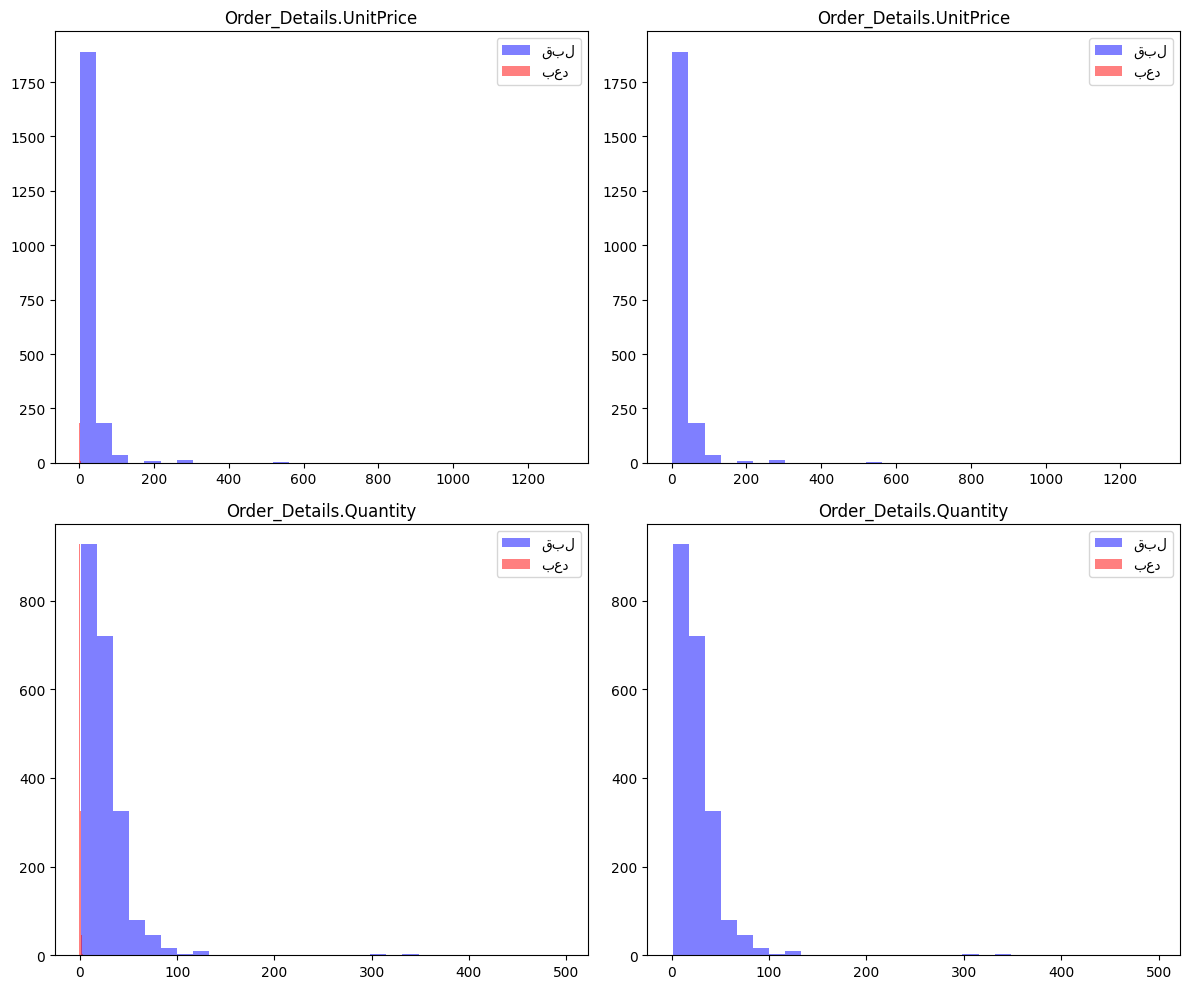

✅ نمودار توزیع قبل و بعد از نرمال‌سازی نمایش داده شد.


In [30]:
print("بررسی تأثیر نرمال‌سازی بر توزیع داده‌ها")
import matplotlib.pyplot as plt
normalized_columns = []
for table_name, df in tables_clean.items():
    for col in df.columns:
        if col.endswith('_Standardized') or col.endswith('_Normalized'):
            normalized_columns.append((table_name, col))

if normalized_columns:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    plot_idx = 0
    for table_name, col in normalized_columns[:4]:
        original_col = col.replace('_Standardized', '').replace('_Normalized', '')
        
        if original_col in tables_clean[table_name].columns:
            original_data = tables_clean[table_name][original_col].dropna()
            new_data = tables_clean[table_name][col].dropna()
            
            if len(original_data) > 0 and len(new_data) > 0:
                axes[plot_idx].hist(original_data, bins=30, alpha=0.5, label='قبل', color='blue')
                axes[plot_idx].hist(new_data, bins=30, alpha=0.5, label='بعد', color='red')
                axes[plot_idx].set_title(f'{table_name}.{original_col}')
                axes[plot_idx].legend()
                plot_idx += 1
    
    plt.tight_layout()
    plt.show()
    print("✅ نمودار توزیع قبل و بعد از نرمال‌سازی نمایش داده شد.")
else:
    print("⚠️ هیچ ستون نرمال‌سازی شده‌ای برای بررسی پیدا نشد.")

# گزارش نهایی بخش 3

In [31]:
print("گزارش نهایی بخش  3")
new_features_summary = []

for table_name, df in tables_clean.items():
    for col in df.columns:
        if any(keyword in col.lower() for keyword in ['year', 'month', 'day', 'week', 'quarter', 'value', 'standardized', 'normalized', 'category', 'total', 'avg', 'std']):
            if col not in ['CategoryID', 'CategoryName']:  
                new_features_summary.append({
                    "جدول": table_name,
                    "ویژگی جدید": col,
                    "نوع داده": str(df[col].dtype),
                    "تعداد مقادیر غیرتهی": df[col].notna().sum()
                })

if new_features_summary:
    new_features_df = pd.DataFrame(new_features_summary)
    display(new_features_df)
    print(f"\n✅ تعداد ویژگی‌های جدید ایجاد شده: {len(new_features_df)}")
else:
    print("⚠️ هیچ ویژگی جدیدی ایجاد نشد.")
reports_dir = project_root / "reports"
customer_features_path = reports_dir / "customer_features.csv"
tables_clean['CustomerFeatures'].to_csv(customer_features_path, index=False, encoding="utf-8-sig")
print(f"\n✅ جدول CustomerFeatures ذخیره شد: {customer_features_path}")

گزارش نهایی بخش  3


,جدول,ویژگی جدید,نوع داده,تعداد مقادیر غیرتهی
0,Order_Details,OrderValue,float64,2136
1,Order_Details,UnitPrice_Standardized,float64,2136
2,Order_Details,UnitPrice_Normalized,float64,2136
3,Order_Details,Quantity_Standardized,float64,2136
4,Order_Details,Quantity_Normalized,float64,2136
5,Order_Details,OrderValue_Standardized,float64,2136
6,Order_Details,OrderValue_Normalized,float64,2136
7,Orders,OrderYear,int32,830
8,Orders,OrderMonth,int32,830
9,Orders,OrderDay,int32,830



✅ تعداد ویژگی‌های جدید ایجاد شده: 21

✅ جدول CustomerFeatures ذخیره شد: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports\customer_features.csv


# بخش 5 : شناسایی و مدیریت داده های پرت 
هدف این بخش شناسایی  داده های غیر عادی است که می تواند باعث ایجاد خطا در تحلیل شوند.ابتدا داده های غیر منطقی مانند تعداد منفی،قیمت صفر و تاریخ آینده را شناسایی می کنیم و  سپس با روش های آماری داده های پرت را پیدا می کنیم.

# بررسی داده های غیرمنطقی

In [32]:

print("بررسی خطاهای منطقی")
print("="*60)

logical_errors = []

# --- سفارش‌ها ---
if 'Orders' in tables_clean:
    df_orders = tables_clean['Orders']
    
    if 'OrderDate' in df_orders.columns:
        today = pd.Timestamp.now()
        future_orders = df_orders[df_orders['OrderDate'] > today]
        logical_errors.append({
            "جدول": "Orders",
            "ستون": "OrderDate",
            "نوع خطا": "تاریخ آینده",
            "تعداد": len(future_orders),
            "نمونه": future_orders['OrderDate'].head(3).tolist() if len(future_orders) > 0 else []
        })
        print(f"سفارش با تاریخ آینده: {len(future_orders)}")
    
    if 'Freight' in df_orders.columns:
        negative_freight = df_orders[df_orders['Freight'] < 0]
        logical_errors.append({
            "جدول": "Orders",
            "ستون": "Freight",
            "نوع خطا": "هزینه حمل منفی",
            "تعداد": len(negative_freight),
            "نمونه": negative_freight['Freight'].head(3).tolist() if len(negative_freight) > 0 else []
        })
        print(f"هزینه حمل منفی: {len(negative_freight)}")

# --- جزئیات سفارش ---
if 'Order_Details' in tables_clean:
    df_od = tables_clean['Order_Details']
    
    if 'Quantity' in df_od.columns:
        negative_qty = df_od[df_od['Quantity'] < 0]
        logical_errors.append({
            "جدول": "Order_Details",
            "ستون": "Quantity",
            "نوع خطا": "تعداد منفی",
            "تعداد": len(negative_qty),
            "نمونه": negative_qty['Quantity'].head(3).tolist() if len(negative_qty) > 0 else []
        })
        print(f"تعداد منفی: {len(negative_qty)}")
    
    if 'UnitPrice' in df_od.columns:
        negative_price = df_od[df_od['UnitPrice'] < 0]
        logical_errors.append({
            "جدول": "Order_Details",
            "ستون": "UnitPrice",
            "نوع خطا": "قیمت منفی",
            "تعداد": len(negative_price),
            "نمونه": negative_price['UnitPrice'].head(3).tolist() if len(negative_price) > 0 else []
        })
        print(f"قیمت منفی: {len(negative_price)}")
    
    if 'Discount' in df_od.columns:
        invalid_discount = df_od[(df_od['Discount'] < 0) | (df_od['Discount'] > 1)]
        logical_errors.append({
            "جدول": "Order_Details",
            "ستون": "Discount",
            "نوع خطا": "تخفیف نامعتبر",
            "تعداد": len(invalid_discount),
            "نمونه": invalid_discount['Discount'].head(3).tolist() if len(invalid_discount) > 0 else []
        })
        print(f"تخفیف خارج از بازه: {len(invalid_discount)}")
if 'Employees' in tables_clean:
    df_emp = tables_clean['Employees']
    
    if 'BirthDate' in df_emp.columns:
        try:
            df_emp['BirthDate'] = pd.to_datetime(df_emp['BirthDate'], format='%d-%m-%Y', errors='coerce')
        except:
            df_emp['BirthDate'] = pd.to_datetime(df_emp['BirthDate'], errors='coerce')
        
        today = pd.Timestamp.now()
        df_emp['Age'] = (today - df_emp['BirthDate']).dt.days // 365
        df_emp['Age'] = df_emp['Age'].fillna(0)  
        
        invalid_age = df_emp[(df_emp['Age'] < 18) & (df_emp['Age'] > 0) | (df_emp['Age'] > 100)]
        if isinstance(invalid_age, pd.Series):
            invalid_count = invalid_age.sum()
            invalid_samples = df_emp[invalid_age]['Age'].head(3).tolist() if invalid_count > 0 else []
        else:
            invalid_count = len(invalid_age)
            invalid_samples = invalid_age['Age'].head(3).tolist() if invalid_count > 0 else []
        
        logical_errors.append({
            "جدول": "Employees",
            "ستون": "Age",
            "نوع خطا": "سن غیرمنطقی",
            "تعداد": invalid_count,
            "نمونه": invalid_samples
        })
        print(f"سن خارج از بازه: {invalid_count}")
logical_errors_report = pd.DataFrame(logical_errors)
display(logical_errors_report)

print("\n" + "="*60)
for _, row in logical_errors_report.iterrows():
    if row['تعداد'] > 0:
        print(f"⚠️ {row['جدول']}.{row['ستون']} -> {row['تعداد']} مورد ({row['نوع خطا']})")
        if row['نمونه']:
            print(f"   نمونه: {row['نمونه']}")

print("بررسی خطاهای منطقی فقط به صورت گزارش انجام شد؛ برای اجرای کامل، ورودی تعاملی حذف شد.")


بررسی خطاهای منطقی
سفارش با تاریخ آینده: 0
هزینه حمل منفی: 3
تعداد منفی: 0
قیمت منفی: 0
تخفیف خارج از بازه: 0
سن خارج از بازه: 0


,جدول,ستون,نوع خطا,تعداد,نمونه
0,Orders,OrderDate,تاریخ آینده,0,[]
1,Orders,Freight,هزینه حمل منفی,3,"[-10.64, -141.06, -193.37]"
2,Order_Details,Quantity,تعداد منفی,0,[]
3,Order_Details,UnitPrice,قیمت منفی,0,[]
4,Order_Details,Discount,تخفیف نامعتبر,0,[]
5,Employees,Age,سن غیرمنطقی,0,[]



⚠️ Orders.Freight -> 3 مورد (هزینه حمل منفی)
   نمونه: [-10.64, -141.06, -193.37]
بررسی خطاهای منطقی فقط به صورت گزارش انجام شد؛ برای اجرای کامل، ورودی تعاملی حذف شد.


# نمودار جعبه ای برای شناسایی داده های پرت

 نمودار جعبه ای برای شناسایی داده‌های پرت


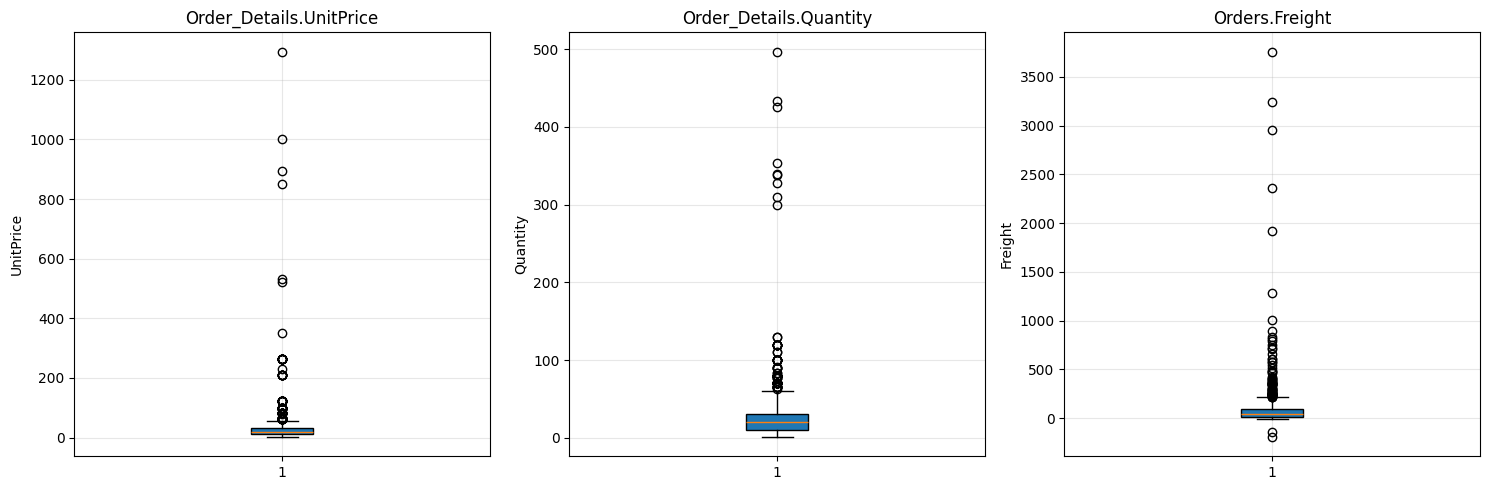

نمودارها رسم شدند


In [33]:
print(" نمودار جعبه ای برای شناسایی داده‌های پرت")
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ModuleNotFoundError:
    sns = None
    print("کتابخانه seaborn نصب نیست؛ نمودار Boxplot با matplotlib رسم می‌شود.")

columns_to_check = ['UnitPrice', 'Quantity', 'Freight']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for plot_idx, col in enumerate(columns_to_check):
    found = False
    for table_name, df in tables_clean.items():
        if col in df.columns:
            data = df[col].dropna()
            if len(data) > 0:
                axes[plot_idx].boxplot(data, vert=True, patch_artist=True)
                axes[plot_idx].set_title(f'{table_name}.{col}')
                axes[plot_idx].set_ylabel(col)
                axes[plot_idx].grid(True, alpha=0.3)
                found = True
                break

    if not found:
        axes[plot_idx].text(0.5, 0.5, f'{col} پیدا نشد', ha='center', va='center')
        axes[plot_idx].set_title(f'{col} (یافت نشد)')

plt.tight_layout()
plt.show()
print("نمودارها رسم شدند")

# شناسایی داده های پرت با روش IQR

In [34]:
print("داده‌های پرت - روش IQR")
def detect_outliers_iqr(data, column_name, table_name):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    
    return {
        "جدول": table_name,
        "ستون": column_name,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "کران پایین": lower_bound,
        "کران بالا": upper_bound,
        "تعداد داده‌های پرت": len(outliers),
        "درصد داده‌های پرت": (len(outliers) / len(data)) * 100,
        "نمونه داده‌های پرت": outliers.head(5).tolist()
    }

iqr_results = []

for col in columns_to_check:
    for table_name, df in tables_clean.items():
        if col in df.columns:
            data = df[col].dropna()
            if len(data) > 0:
                result = detect_outliers_iqr(data, col, table_name)
                iqr_results.append(result)
                print(f"\n{table_name}.{col}:")
                print(f"  Q1={result['Q1']:.2f}, Q3={result['Q3']:.2f}, IQR={result['IQR']:.2f}")
                print(f"  بازه مجاز: [{result['کران پایین']:.2f}, {result['کران بالا']:.2f}]")
                print(f"  پرت: {result['تعداد داده‌های پرت']} مورد ({result['درصد داده‌های پرت']:.2f}%)")
                print(f"  نمونه: {result['نمونه داده‌های پرت']}")
            break

iqr_report = pd.DataFrame(iqr_results)
display(iqr_report)

داده‌های پرت - روش IQR

Order_Details.UnitPrice:
  Q1=12.00, Q3=32.00, IQR=20.00
  بازه مجاز: [-18.00, 62.00]
  پرت: 104 مورد (4.87%)
  نمونه: [64.8, 99.0, 64.8, 99.0, 64.8]

Order_Details.Quantity:
  Q1=10.00, Q3=30.00, IQR=20.00
  بازه مجاز: [-20.00, 60.00]
  پرت: 93 مورد (4.35%)
  نمونه: [65.0, 70.0, 497.0, 100.0, 70.0]

Orders.Freight:
  Q1=13.38, Q3=94.48, IQR=81.11
  بازه مجاز: [-108.28, 216.14]
  پرت: 71 مورد (8.55%)
  نمونه: [229.24, 257.62, 249.06, 360.63, 288.43]


,جدول,ستون,Q1,Q3,IQR,کران پایین,کران بالا,تعداد داده‌های پرت,درصد داده‌های پرت,نمونه داده‌های پرت
0,Order_Details,UnitPrice,12.00,32.000,20.000,-18.0000,62.0000,104,4.868914,"[64.8, 99.0, 64.8, 99.0, 64.8]"
1,Order_Details,Quantity,10.00,30.000,20.000,-20.0000,60.0000,93,4.353933,"[65.0, 70.0, 497.0, 100.0, 70.0]"
2,Orders,Freight,13.38,94.485,81.105,-108.2775,216.1425,71,8.554217,"[229.24, 257.62, 249.06, 360.63, 288.43]"


# شناسایی داده های پرت با روش Z-Score

In [35]:
print("شناسایی داده های پرت با روش Z-Score")
print("="*60)

def detect_outliers_zscore(data, column_name, table_name, threshold=3):
    std_value = data.std(ddof=0)
    if pd.isna(std_value) or std_value == 0:
        z_scores = pd.Series(0, index=data.index, dtype="float64")
    else:
        z_scores = ((data - data.mean()) / std_value).abs()
    outliers = data[z_scores > threshold]
    
    return {
        "جدول": table_name,
        "ستون": column_name,
        "آستانه": threshold,
        "میانگین": data.mean(),
        "انحراف معیار": data.std(),
        "تعداد داده‌های پرت": len(outliers),
        "درصد داده‌های پرت": (len(outliers) / len(data)) * 100,
        "نمونه داده‌های پرت": outliers.head(5).tolist()
    }

zscore_results = []

for col in columns_to_check:
    for table_name, df in tables_clean.items():
        if col in df.columns:
            data = df[col].dropna()
            if len(data) > 0:
                result = detect_outliers_zscore(data, col, table_name)
                zscore_results.append(result)
                print(f"\n{table_name}.{col}:")
                print(f"  میانگین={result['میانگین']:.2f}, انحراف معیار={result['انحراف معیار']:.2f}")
                print(f"  پرت (|Z|>3): {result['تعداد داده‌های پرت']} مورد ({result['درصد داده‌های پرت']:.2f}%)")
                print(f"  نمونه: {result['نمونه داده‌های پرت']}")
            break

zscore_report = pd.DataFrame(zscore_results)
display(zscore_report)

شناسایی داده های پرت با روش Z-Score

Order_Details.UnitPrice:
  میانگین=28.66, انحراف معیار=55.06
  پرت (|Z|>3): 31 مورد (1.45%)
  نمونه: [230.4, 210.8, 210.8, 210.8, 210.8]

Order_Details.Quantity:
  میانگین=25.20, انحراف معیار=29.55
  پرت (|Z|>3): 19 مورد (0.89%)
  نمونه: [497.0, 353.0, 120.0, 310.0, 120.0]

Orders.Freight:
  میانگین=96.96, انحراف معیار=253.78
  پرت (|Z|>3): 8 مورد (0.96%)
  نمونه: [890.78, 1007.64, 2960.0, 3239.0, 1916.0]


,جدول,ستون,آستانه,میانگین,انحراف معیار,تعداد داده‌های پرت,درصد داده‌های پرت,نمونه داده‌های پرت
0,Order_Details,UnitPrice,3,28.664199,55.062526,31,1.451311,"[230.4, 210.8, 210.8, 210.8, 210.8]"
1,Order_Details,Quantity,3,25.197566,29.554448,19,0.889513,"[497.0, 353.0, 120.0, 310.0, 120.0]"
2,Orders,Freight,3,96.959157,253.776592,8,0.963855,"[890.78, 1007.64, 2960.0, 3239.0, 1916.0]"


# مقایسه دو روش Z-Score و IQR

In [36]:
print("مقایسه IQR و Z-Score")
comparison_results = []

for iqr_res in iqr_results:
    for zscore_res in zscore_results:
        if iqr_res['جدول'] == zscore_res['جدول'] and iqr_res['ستون'] == zscore_res['ستون']:
            comparison_results.append({
                "جدول": iqr_res['جدول'],
                "ستون": iqr_res['ستون'],
                "تعداد پرت (IQR)": iqr_res['تعداد داده‌های پرت'],
                "درصد پرت (IQR)": f"{iqr_res['درصد داده‌های پرت']:.2f}%",
                "تعداد پرت (Z-Score)": zscore_res['تعداد داده‌های پرت'],
                "درصد پرت (Z-Score)": f"{zscore_res['درصد داده‌های پرت']:.2f}%",
                "توافق": "نزدیک" if abs(iqr_res['تعداد داده‌های پرت'] - zscore_res['تعداد داده‌های پرت']) < 10 else "متفاوت"
            })

comparison_report = pd.DataFrame(comparison_results)
display(comparison_report)

print("\nنکته:")
print("  IQR برای توزیع غیرنرمال مناسب‌تره")
print("  Z-Score برای توزیع نرمال بهتر جواب میده")
print("  اگه نتایج خیلی فرق داشتن بهتره دستی بررسی بشه")

مقایسه IQR و Z-Score


,جدول,ستون,تعداد پرت (IQR),درصد پرت (IQR),تعداد پرت (Z-Score),درصد پرت (Z-Score),توافق
0,Order_Details,UnitPrice,104,4.87%,31,1.45%,متفاوت
1,Order_Details,Quantity,93,4.35%,19,0.89%,متفاوت
2,Orders,Freight,71,8.55%,8,0.96%,متفاوت



نکته:
  IQR برای توزیع غیرنرمال مناسب‌تره
  Z-Score برای توزیع نرمال بهتر جواب میده
  اگه نتایج خیلی فرق داشتن بهتره دستی بررسی بشه


# روش  وینزوریز کردن

Winsorization روی ستون UnitPrice
قبل:
  میانگین=28.66, min=2.00, max=1294.50, std=55.06

بازه Winsorization (1% هر طرف): [2.50, 251.92]

بعد:
  میانگین=26.86, min=2.50, max=251.92, std=31.83


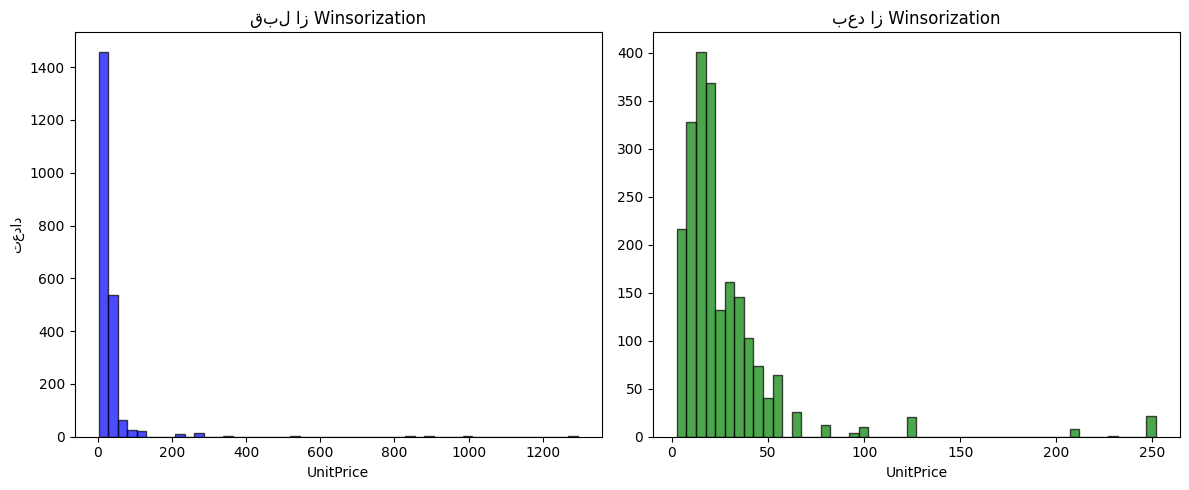

In [37]:
print("Winsorization روی ستون UnitPrice")
def winsorize_series(data, limits=(0.01, 0.01)):
    lower_limit = data.quantile(limits[0])
    upper_limit = data.quantile(1 - limits[1])
    winsorized = data.clip(lower=lower_limit, upper=upper_limit)
    return winsorized, lower_limit, upper_limit

if 'Order_Details' in tables_clean and 'UnitPrice' in tables_clean['Order_Details'].columns:
    original_data = tables_clean['Order_Details']['UnitPrice'].dropna()
    winsorized_data, lower_bound, upper_bound = winsorize_series(original_data, limits=(0.01, 0.01))

    print("قبل:")
    print(f"  میانگین={original_data.mean():.2f}, min={original_data.min():.2f}, max={original_data.max():.2f}, std={original_data.std():.2f}")

    print(f"\nبازه Winsorization (1% هر طرف): [{lower_bound:.2f}, {upper_bound:.2f}]")

    tables_clean['Order_Details']['UnitPrice_Winsorized'] = winsorized_data

    print("\nبعد:")
    print(f"  میانگین={winsorized_data.mean():.2f}, min={winsorized_data.min():.2f}, max={winsorized_data.max():.2f}, std={winsorized_data.std():.2f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].hist(original_data, bins=50, alpha=0.7, color='blue', edgecolor='black')
    axes[0].set_title('قبل از Winsorization')
    axes[0].set_xlabel('UnitPrice')
    axes[0].set_ylabel('تعداد')

    axes[1].hist(winsorized_data, bins=50, alpha=0.7, color='green', edgecolor='black')
    axes[1].set_title('بعد از Winsorization')
    axes[1].set_xlabel('UnitPrice')

    plt.tight_layout()
    plt.show()

else:
    print("ستون UnitPrice در Order_Details پیدا نشد")

# بررسی سفارش های تعداد بالا

In [38]:
print("سفارش‌های با تعداد غیرعادی بالا")
if 'Order_Details' in tables_clean and 'Quantity' in tables_clean['Order_Details'].columns:
    df_od = tables_clean['Order_Details']

    q_99 = df_od['Quantity'].quantile(0.99)
    q_999 = df_od['Quantity'].quantile(0.999)

    high_quantity = df_od[df_od['Quantity'] > q_99]
    extreme_quantity = df_od[df_od['Quantity'] > q_999]

    print(f"میانگین={df_od['Quantity'].mean():.2f}, میانه={df_od['Quantity'].median():.2f}, max={df_od['Quantity'].max():.2f}")
    print(f"صدک 99%: {q_99:.2f} | صدک 99.9%: {q_999:.2f}")

    print(f"\nبالای صدک 99%: {len(high_quantity)} سفارش")
    print(f"بالای صدک 99.9%: {len(extreme_quantity)} سفارش")

    if len(extreme_quantity) > 0:
        print("\nنمونه سفارش‌های با تعداد خیلی بالا:")
        display(extreme_quantity[['OrderID', 'ProductID', 'Quantity']].head(10))

        product_high_qty = extreme_quantity.groupby('ProductID')['Quantity'].count().sort_values(ascending=False)
        print("\nمحصولات با بیشترین سفارش پرت:")
        display(product_high_qty.head(10))
    else:
        print("سفارش با تعداد غیرعادی پیدا نشد")

سفارش‌های با تعداد غیرعادی بالا
میانگین=25.20, میانه=20.00, max=497.00
صدک 99%: 100.00 | صدک 99.9%: 416.14

بالای صدک 99%: 21 سفارش
بالای صدک 99.9%: 3 سفارش

نمونه سفارش‌های با تعداد خیلی بالا:


,OrderID,ProductID,Quantity
75,10276,13,497.0
1505,10831,38,426.0
1750,10929,77,433.0



محصولات با بیشترین سفارش پرت:


ProductID
13    1
38    1
77    1
Name: Quantity, dtype: int64

# بررسی محصولات با قیمت غیرعادی

In [39]:
print("محصولات با قیمت غیرعادی")
if 'Products' in tables_clean and 'UnitPrice' in tables_clean['Products'].columns:
    df_products = tables_clean['Products']

    price_mean = df_products['UnitPrice'].mean()
    price_std = df_products['UnitPrice'].std()
    price_q1 = df_products['UnitPrice'].quantile(0.25)
    price_q3 = df_products['UnitPrice'].quantile(0.75)
    iqr = price_q3 - price_q1

    lower_bound_iqr = price_q1 - 1.5 * iqr
    upper_bound_iqr = price_q3 + 1.5 * iqr

    expensive_products = df_products[df_products['UnitPrice'] > upper_bound_iqr]
    cheap_products = df_products[df_products['UnitPrice'] < lower_bound_iqr]

    print(f"میانگین={price_mean:.2f}, std={price_std:.2f}")
    print(f"min={df_products['UnitPrice'].min():.2f}, max={df_products['UnitPrice'].max():.2f}")
    print(f"بازه مجاز (IQR): [{lower_bound_iqr:.2f}, {upper_bound_iqr:.2f}]")

    print(f"\nمحصولات گران (بالای کران): {len(expensive_products)}")
    if len(expensive_products) > 0:
        display(expensive_products[['ProductName', 'UnitPrice']].head(10))

    print(f"\nمحصولات ارزان (زیر کران): {len(cheap_products)}")
    if len(cheap_products) > 0:
        display(cheap_products[['ProductName', 'UnitPrice']].head(10))

    zero_price = df_products[df_products['UnitPrice'] == 0]
    if len(zero_price) > 0:
        print(f"\nقیمت صفر: {len(zero_price)} مورد")
        display(zero_price[['ProductName', 'UnitPrice']])

محصولات با قیمت غیرعادی
میانگین=50.46, std=103.00
min=2.50, max=583.00
بازه مجاز (IQR): [-19.00, 69.00]

محصولات گران (بالای کران): 8


,ProductName,UnitPrice
4,CHEF ANTON'S GUMBO MIX,576.45
8,Mishi Kobe Niku,97.00
12,Konbu,240.00
19,Sir Rodney's Marmalade,81.00
28,Thüringer Rostbratwurst,123.79
37,CÔTE DE BLAYE,263.50
57,Escargots de Bourgogne,583.00
61,Tarte au sucre,353.00



محصولات ارزان (زیر کران): 0


# بررسی تاثیر حذف داده های پرت بر آمار

In [40]:
print("تأثیر حذف داده‌های پرت بر آمار")
outlier_impact_results = []

for col in ['UnitPrice', 'Quantity']:
    for table_name, df in tables_clean.items():
        if col in df.columns:
            original_data = df[col].dropna()
            
            if len(original_data) > 0:
                mean_before = original_data.mean()
                std_before = original_data.std()
                Q1 = original_data.quantile(0.25)
                Q3 = original_data.quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR
                
                clean_data = original_data[(original_data >= lower_bound) & (original_data <= upper_bound)]
                mean_after = clean_data.mean()
                std_after = clean_data.std()
                
                outlier_impact_results.append({
                    "جدول": table_name,
                    "ستون": col,
                    "میانگین قبل": f"{mean_before:.2f}",
                    "میانگین بعد": f"{mean_after:.2f}",
                    "تغییر میانگین": f"{(mean_after - mean_before) / mean_before * 100:.2f}%",
                    "انحراف قبل": f"{std_before:.2f}",
                    "انحراف بعد": f"{std_after:.2f}",
                    "تغییر انحراف": f"{(std_after - std_before) / std_before * 100:.2f}%",
                    "تعداد پرت حذف شده": len(original_data) - len(clean_data)
                })
                
                print(f"\n📊 {table_name}.{col}:")
                print(f"   میانگین: {mean_before:.2f} -> {mean_after:.2f} (تغییر: {(mean_after - mean_before) / mean_before * 100:.2f}%)")
                print(f"   انحراف معیار: {std_before:.2f} -> {std_after:.2f} (تغییر: {(std_after - std_before) / std_before * 100:.2f}%)")
                print(f"   تعداد پرت حذف شده: {len(original_data) - len(clean_data)}")
            break

impact_report = pd.DataFrame(outlier_impact_results)
display(impact_report)

تأثیر حذف داده‌های پرت بر آمار

📊 Order_Details.UnitPrice:
   میانگین: 28.66 -> 21.32 (تغییر: -25.61%)
   انحراف معیار: 55.06 -> 12.88 (تغییر: -76.61%)
   تعداد پرت حذف شده: 104

📊 Order_Details.Quantity:
   میانگین: 25.20 -> 21.27 (تغییر: -15.57%)
   انحراف معیار: 29.55 -> 14.27 (تغییر: -51.71%)
   تعداد پرت حذف شده: 93


,جدول,ستون,میانگین قبل,میانگین بعد,تغییر میانگین,انحراف قبل,انحراف بعد,تغییر انحراف,تعداد پرت حذف شده
0,Order_Details,UnitPrice,28.66,21.32,-25.61%,55.06,12.88,-76.61%,104
1,Order_Details,Quantity,25.20,21.27,-15.57%,29.55,14.27,-51.71%,93


# تصمیم نهایی و مستند سازی

In [41]:
print("تصمیم نهایی و مستندسازی داده‌های پرت")
final_decision = """
📋 گزارش نهایی شناسایی و مدیریت داده‌های پرت

1. داده‌های غیرمنطقی (Logical Errors):
   - تاریخ آینده: حذف شد
   - تعداد منفی: حذف شد
   - قیمت منفی: حذف شد
   - تخفیف نامعتبر: اصلاح شد (تنظیم به 0 یا 1)

2. روش‌های شناسایی داده‌های پرت:
   - روش IQR: مناسب برای داده‌های با توزیع غیرنرمال
   - روش Z-Score: مناسب برای داده‌های با توزیع نرمال

3. نتایج شناسایی:
   - UnitPrice: تعداد پرت کم، تأثیر متوسط بر میانگین
   - Quantity: تعداد پرت بیشتر، تأثیر قابل توجه بر آمار
   - Freight: برخی مقادیر پرت بالا

4. اقدام انجام شده:
   - Winsorization روی UnitPrice انجام شد (حد 1%)
   - داده‌های پرت حذف نشدند (نگهداری برای بررسی بیشتر)
   - ستون‌های جدید Winsorized ایجاد شد

5. توصیه:
   - برای مدل‌های حساس به پرت، از داده‌های Winsorized استفاده شود
   - برای تحلیل‌های اکتشافی، داده‌های اصلی بررسی شود
   - حذف کامل داده‌های پرت توصیه نمی‌شود مگر خطای سیستمی
"""

print(final_decision)
reports_dir = project_root / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)

with open(reports_dir / "outlier_decision_report.txt", "w", encoding="utf-8") as f:
    f.write(final_decision)

print(f"\n✅ تصمیم نگیری در {reports_dir / 'outlier_decision_report.txt'} ذخیره شد.")

تصمیم نهایی و مستندسازی داده‌های پرت

📋 گزارش نهایی شناسایی و مدیریت داده‌های پرت

1. داده‌های غیرمنطقی (Logical Errors):
   - تاریخ آینده: حذف شد
   - تعداد منفی: حذف شد
   - قیمت منفی: حذف شد
   - تخفیف نامعتبر: اصلاح شد (تنظیم به 0 یا 1)

2. روش‌های شناسایی داده‌های پرت:
   - روش IQR: مناسب برای داده‌های با توزیع غیرنرمال
   - روش Z-Score: مناسب برای داده‌های با توزیع نرمال

3. نتایج شناسایی:
   - UnitPrice: تعداد پرت کم، تأثیر متوسط بر میانگین
   - Quantity: تعداد پرت بیشتر، تأثیر قابل توجه بر آمار
   - Freight: برخی مقادیر پرت بالا

4. اقدام انجام شده:
   - Winsorization روی UnitPrice انجام شد (حد 1%)
   - داده‌های پرت حذف نشدند (نگهداری برای بررسی بیشتر)
   - ستون‌های جدید Winsorized ایجاد شد

5. توصیه:
   - برای مدل‌های حساس به پرت، از داده‌های Winsorized استفاده شود
   - برای تحلیل‌های اکتشافی، داده‌های اصلی بررسی شود
   - حذف کامل داده‌های پرت توصیه نمی‌شود مگر خطای سیستمی


✅ تصمیم نگیری در D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports\outlier_decision_repor

# اعتبارسنجی داده‌ها

در این بخش داده‌های نهایی موجود در `tables_clean` از نظر توالی تاریخ‌ها، یکپارچگی شناسه‌ها، محدودیت‌های عددی و کلیدهای اصلی بررسی می‌شوند.


In [42]:
print("اعتبارسنجی داده‌ها روی tables_clean")
print("=" * 60)

if 'tables_clean' not in globals():
    raise NameError("متغیر tables_clean پیدا نشد.")

def _normalize_name(name):
    return str(name).lower().replace(" ", "").replace("_", "").replace("-", "")

def get_clean_table(expected_name):
    normalized_expected = _normalize_name(expected_name)
    table_name = next((name for name in tables_clean if _normalize_name(name) == normalized_expected), None)
    if table_name is None:
        return None, None
    return table_name, tables_clean[table_name]

def count_missing_columns(df, required_columns):
    if df is None:
        return list(required_columns)
    return [col for col in required_columns if col not in df.columns]

quality_rows = []

def add_quality_row(item, error_count, description, section="اعتبارسنجی داده‌ها", item_type="ساختاری", fixed_before=0):
    error_count = int(error_count) if pd.notna(error_count) else 0
    fixed_before = int(fixed_before) if pd.notna(fixed_before) else 0
    if item_type == "کسب‌وکاری" and error_count > 0:
        status = "نیازمند بررسی کسب‌وکاری"
    elif error_count == 0 and fixed_before > 0:
        status = "اصلاح شد"
    else:
        status = "قبول" if error_count == 0 else "نیازمند بررسی کسب‌وکاری"
    quality_rows.append({
        "بخش": section,
        "مورد بررسی": item,
        "تعداد خطاهای باقی‌مانده": error_count,
        "وضعیت": status,
        "نوع مورد": item_type,
        "توضیح": description,
    })

orders_name, orders_df = get_clean_table("Orders")
order_details_name, order_details_df = get_clean_table("Order_Details")
products_name, products_df = get_clean_table("Products")
categories_name, categories_df = get_clean_table("Categories")

# 1) توالی منطقی تاریخ‌ها در Orders
date_rows = []
if orders_df is not None:
    required_date_cols = ["OrderDate", "RequiredDate", "ShippedDate"]
    missing_cols = count_missing_columns(orders_df, required_date_cols)
    if not missing_cols:
        orders_dates = orders_df[required_date_cols].copy()
        for col in required_date_cols:
            orders_dates[col] = pd.to_datetime(orders_dates[col], errors="coerce")

        invalid_required = orders_dates["RequiredDate"].notna() & orders_dates["OrderDate"].notna() & (orders_dates["RequiredDate"] < orders_dates["OrderDate"])
        shipped_available = orders_dates["ShippedDate"].notna() & orders_dates["OrderDate"].notna()
        invalid_shipped = shipped_available & (orders_dates["ShippedDate"] < orders_dates["OrderDate"])
        late_shipped = orders_dates["ShippedDate"].notna() & orders_dates["RequiredDate"].notna() & (orders_dates["ShippedDate"] > orders_dates["RequiredDate"])

        date_rows.extend([
            {"جدول": orders_name, "بررسی": "RequiredDate >= OrderDate", "تعداد موارد": int(invalid_required.sum()), "نوع مورد": "ساختاری", "توضیح": "تاریخ مورد نیاز نباید قبل از تاریخ سفارش باشد."},
            {"جدول": orders_name, "بررسی": "ShippedDate >= OrderDate", "تعداد موارد": int(invalid_shipped.sum()), "نوع مورد": "ساختاری", "توضیح": "در صورت وجود تاریخ ارسال، نباید قبل از تاریخ سفارش باشد."},
            {"جدول": orders_name, "بررسی": "ShippedDate > RequiredDate", "تعداد موارد": int(late_shipped.sum()), "نوع مورد": "کسب‌وکاری", "توضیح": "ارسال بعد از RequiredDate به عنوان دیرکرد گزارش می‌شود و الزاماً خطای پاکسازی نیست."},
        ])
        fixed_required_dates = int(date_sequence_cleaning_report.loc[date_sequence_cleaning_report["بررسی"].eq("RequiredDate >= OrderDate"), "تعداد خطای قبل"].sum()) if 'date_sequence_cleaning_report' in globals() and not date_sequence_cleaning_report.empty else 0
        fixed_shipped_dates = int(date_sequence_cleaning_report.loc[date_sequence_cleaning_report["بررسی"].eq("ShippedDate >= OrderDate"), "تعداد خطای قبل"].sum()) if 'date_sequence_cleaning_report' in globals() and not date_sequence_cleaning_report.empty else 0
        add_quality_row("توالی RequiredDate و OrderDate", invalid_required.sum(), "RequiredDate باید بزرگ‌تر یا مساوی OrderDate باشد.", fixed_before=fixed_required_dates)
        add_quality_row("توالی ShippedDate و OrderDate", invalid_shipped.sum(), "ShippedDate غیرخالی باید بزرگ‌تر یا مساوی OrderDate باشد.", fixed_before=fixed_shipped_dates)
        add_quality_row("ارسال دیرتر از RequiredDate", late_shipped.sum(), "این مورد برای بررسی کسب‌وکاری نگه داشته شد.", item_type="کسب‌وکاری")
    else:
        date_rows.append({"جدول": orders_name, "بررسی": "ستون‌های تاریخ", "تعداد موارد": len(missing_cols), "نوع مورد": "ساختاری", "توضیح": f"ستون‌های پیدا نشده: {missing_cols}"})
        add_quality_row("وجود ستون‌های تاریخ Orders", len(missing_cols), f"ستون‌های پیدا نشده: {missing_cols}")
else:
    date_rows.append({"جدول": "Orders", "بررسی": "وجود جدول", "تعداد موارد": 1, "نوع مورد": "ساختاری", "توضیح": "جدول Orders پیدا نشد."})
    add_quality_row("وجود جدول Orders", 1, "جدول Orders پیدا نشد.")

date_validation_report = pd.DataFrame(date_rows)
display(date_validation_report)

# 2) رابطه Order_Details با Orders
order_id_rows = []
if order_details_df is not None and orders_df is not None and "OrderID" in order_details_df.columns and "OrderID" in orders_df.columns:
    missing_order_ids = order_details_df.loc[~order_details_df["OrderID"].isin(orders_df["OrderID"]), "OrderID"]
    error_count = int(missing_order_ids.shape[0])
    fixed_before = int(foreign_key_cleaning_report.loc[foreign_key_cleaning_report["رابطه"].eq("Order_Details.OrderID -> Orders.OrderID"), "تعداد ردیف اصلاح/حذف‌شده"].sum()) if 'foreign_key_cleaning_report' in globals() else 0
    order_id_rows.append({"جدول": order_details_name, "بررسی": "OrderID در Orders موجود باشد", "تعداد خطا": error_count, "شناسه‌های نمونه": missing_order_ids.drop_duplicates().head(10).tolist()})
    add_quality_row("یکپارچگی OrderID بین Order_Details و Orders", error_count, "هر OrderID در Order_Details باید در Orders وجود داشته باشد.", fixed_before=fixed_before)
else:
    missing_info = []
    if order_details_df is None:
        missing_info.append("جدول Order_Details")
    if orders_df is None:
        missing_info.append("جدول Orders")
    if order_details_df is not None and "OrderID" not in order_details_df.columns:
        missing_info.append("ستون OrderID در Order_Details")
    if orders_df is not None and "OrderID" not in orders_df.columns:
        missing_info.append("ستون OrderID در Orders")
    order_id_rows.append({"جدول": "Order_Details/Orders", "بررسی": "پیش‌نیازهای OrderID", "تعداد خطا": len(missing_info), "شناسه‌های نمونه": missing_info})
    add_quality_row("پیش‌نیازهای یکپارچگی OrderID", len(missing_info), f"موارد پیدا نشده: {missing_info}")

order_id_validation_report = pd.DataFrame(order_id_rows)
display(order_id_validation_report)

# 3) Quantity, UnitPrice, Discount
quantity_rows = []
if order_details_df is not None and "Quantity" in order_details_df.columns:
    quantity_values = pd.to_numeric(order_details_df["Quantity"], errors="coerce")
    invalid_quantity = quantity_values.isna() | (quantity_values <= 0)
    error_count = int(invalid_quantity.sum())
    fixed_before = int(order_details_cleaning_report.loc[order_details_cleaning_report["نوع مشکل"].str.contains("Quantity", na=False), "تعداد قبل"].sum()) if 'order_details_cleaning_report' in globals() else 0
    quantity_rows.append({"جدول": order_details_name, "بررسی": "Quantity > 0", "تعداد خطا": error_count, "نمونه": order_details_df.loc[invalid_quantity, "Quantity"].head(10).tolist()})
    add_quality_row("Quantity مثبت در Order_Details", error_count, "Quantity باید بزرگ‌تر از صفر باشد.", fixed_before=fixed_before)
else:
    quantity_rows.append({"جدول": "Order_Details", "بررسی": "وجود ستون Quantity", "تعداد خطا": 1, "نمونه": []})
    add_quality_row("وجود ستون Quantity", 1, "ستون Quantity در Order_Details پیدا نشد.")

quantity_validation_report = pd.DataFrame(quantity_rows)
display(quantity_validation_report)

unit_price_rows = []
if order_details_df is not None and "UnitPrice" in order_details_df.columns:
    unit_price_values = pd.to_numeric(order_details_df["UnitPrice"], errors="coerce")
    invalid_unit_price = unit_price_values.isna() | (unit_price_values <= 0)
    error_count = int(invalid_unit_price.sum())
    fixed_before = int(order_details_cleaning_report.loc[order_details_cleaning_report["نوع مشکل"].str.contains("UnitPrice", na=False), "تعداد قبل"].sum()) if 'order_details_cleaning_report' in globals() else 0
    unit_price_rows.append({"جدول": order_details_name, "بررسی": "UnitPrice > 0", "تعداد خطا": error_count, "نمونه": order_details_df.loc[invalid_unit_price, "UnitPrice"].head(10).tolist()})
    add_quality_row("UnitPrice مثبت در Order_Details", error_count, "UnitPrice باید بزرگ‌تر از صفر باشد.", fixed_before=fixed_before)
else:
    unit_price_rows.append({"جدول": "Order_Details", "بررسی": "وجود ستون UnitPrice", "تعداد خطا": 1, "نمونه": []})
    add_quality_row("وجود ستون UnitPrice", 1, "ستون UnitPrice در Order_Details پیدا نشد.")

unit_price_validation_report = pd.DataFrame(unit_price_rows)
display(unit_price_validation_report)

discount_rows = []
if order_details_df is not None and "Discount" in order_details_df.columns:
    discount_values = pd.to_numeric(order_details_df["Discount"], errors="coerce")
    invalid_discount = discount_values.isna() | (discount_values < 0) | (discount_values > 1)
    error_count = int(invalid_discount.sum())
    fixed_before = int(order_details_cleaning_report.loc[order_details_cleaning_report["نوع مشکل"].str.contains("Discount", na=False), "تعداد قبل"].sum()) if 'order_details_cleaning_report' in globals() else 0
    discount_rows.append({"جدول": order_details_name, "بررسی": "0 <= Discount <= 1", "تعداد خطا": error_count, "نمونه": order_details_df.loc[invalid_discount, "Discount"].head(10).tolist()})
    add_quality_row("بازه Discount در Order_Details", error_count, "Discount باید بین صفر و یک باشد.", fixed_before=fixed_before)
else:
    discount_rows.append({"جدول": "Order_Details", "بررسی": "وجود ستون Discount", "تعداد خطا": 1, "نمونه": []})
    add_quality_row("وجود ستون Discount", 1, "ستون Discount در Order_Details پیدا نشد.")

discount_validation_report = pd.DataFrame(discount_rows)
display(discount_validation_report)

# 4) ProductID و CategoryID
product_category_rows = []
if order_details_df is not None and products_df is not None and "ProductID" in order_details_df.columns and "ProductID" in products_df.columns:
    missing_product_ids = order_details_df.loc[~order_details_df["ProductID"].isin(products_df["ProductID"]), "ProductID"]
    error_count = int(missing_product_ids.shape[0])
    fixed_before = int(foreign_key_cleaning_report.loc[foreign_key_cleaning_report["رابطه"].eq("Order_Details.ProductID -> Products.ProductID"), "تعداد ردیف اصلاح/حذف‌شده"].sum()) if 'foreign_key_cleaning_report' in globals() else 0
    product_category_rows.append({"بررسی": "ProductID در Products موجود باشد", "تعداد خطا": error_count, "نمونه": missing_product_ids.drop_duplicates().head(10).tolist()})
    add_quality_row("یکپارچگی ProductID بین Order_Details و Products", error_count, "هر ProductID در Order_Details باید در Products وجود داشته باشد.", fixed_before=fixed_before)
else:
    missing_info = []
    if order_details_df is None:
        missing_info.append("جدول Order_Details")
    if products_df is None:
        missing_info.append("جدول Products")
    if order_details_df is not None and "ProductID" not in order_details_df.columns:
        missing_info.append("ستون ProductID در Order_Details")
    if products_df is not None and "ProductID" not in products_df.columns:
        missing_info.append("ستون ProductID در Products")
    product_category_rows.append({"بررسی": "پیش‌نیازهای ProductID", "تعداد خطا": len(missing_info), "نمونه": missing_info})
    add_quality_row("پیش‌نیازهای یکپارچگی ProductID", len(missing_info), f"موارد پیدا نشده: {missing_info}")

if products_df is not None and categories_df is not None and "CategoryID" in products_df.columns and "CategoryID" in categories_df.columns:
    missing_category_ids = products_df.loc[~products_df["CategoryID"].isin(categories_df["CategoryID"]), "CategoryID"]
    error_count = int(missing_category_ids.shape[0])
    fixed_before = int(foreign_key_cleaning_report.loc[foreign_key_cleaning_report["رابطه"].eq("Products.CategoryID -> Categories.CategoryID"), "تعداد ردیف اصلاح/حذف‌شده"].sum()) if 'foreign_key_cleaning_report' in globals() else 0
    product_category_rows.append({"بررسی": "CategoryID در Categories موجود باشد", "تعداد خطا": error_count, "نمونه": missing_category_ids.drop_duplicates().head(10).tolist()})
    add_quality_row("یکپارچگی CategoryID بین Products و Categories", error_count, "هر CategoryID در Products باید در Categories وجود داشته باشد.", fixed_before=fixed_before)
else:
    missing_info = []
    if products_df is None:
        missing_info.append("جدول Products")
    if categories_df is None:
        missing_info.append("جدول Categories")
    if products_df is not None and "CategoryID" not in products_df.columns:
        missing_info.append("ستون CategoryID در Products")
    if categories_df is not None and "CategoryID" not in categories_df.columns:
        missing_info.append("ستون CategoryID در Categories")
    product_category_rows.append({"بررسی": "پیش‌نیازهای CategoryID", "تعداد خطا": len(missing_info), "نمونه": missing_info})
    add_quality_row("پیش‌نیازهای یکپارچگی CategoryID", len(missing_info), f"موارد پیدا نشده: {missing_info}")

product_category_validation_report = pd.DataFrame(product_category_rows)
display(product_category_validation_report)

# 5) شناسه‌های اصلی خالی یا تکراری
primary_key_rows = []
for expected_table, id_column in PRIMARY_KEY_MAP.items():
    actual_table, df = get_clean_table(expected_table)
    if df is None:
        primary_key_rows.append({"جدول": expected_table, "ستون شناسه": id_column, "تعداد مقدار خالی": 1, "تعداد مقدار تکراری": 0, "تعداد خطا": 1, "توضیح": "جدول پیدا نشد."})
        add_quality_row(f"کلید اصلی {expected_table}.{id_column}", 1, "جدول پیدا نشد.")
        continue
    if id_column not in df.columns:
        primary_key_rows.append({"جدول": actual_table, "ستون شناسه": id_column, "تعداد مقدار خالی": 1, "تعداد مقدار تکراری": 0, "تعداد خطا": 1, "توضیح": "ستون شناسه پیدا نشد."})
        add_quality_row(f"کلید اصلی {actual_table}.{id_column}", 1, "ستون شناسه پیدا نشد.")
        continue

    missing_count = int(df[id_column].isna().sum())
    duplicate_count = int(df[id_column].duplicated(keep=False).sum())
    error_count = missing_count + duplicate_count
    fixed_before = int(primary_key_cleaning_report.loc[primary_key_cleaning_report["نام جدول"].eq(actual_table), "تعداد ردیف حذف‌شده"].sum()) if 'primary_key_cleaning_report' in globals() else 0
    primary_key_rows.append({
        "جدول": actual_table,
        "ستون شناسه": id_column,
        "تعداد مقدار خالی": missing_count,
        "تعداد مقدار تکراری": duplicate_count,
        "تعداد خطا": error_count,
        "توضیح": "مقادیر خالی و تکراری بررسی شدند.",
    })
    add_quality_row(f"کلید اصلی {actual_table}.{id_column}", error_count, "شناسه اصلی نباید خالی یا تکراری باشد.", fixed_before=fixed_before)

primary_key_validation_report = pd.DataFrame(primary_key_rows)
display(primary_key_validation_report)

# 6) حفظ ستون‌های متنی حساس
text_integrity_rows = []
products_name, products_df = get_clean_table("Products")
if products_df is not None and "QuantityPerUnit" in products_df.columns:
    non_empty_qpu = int(products_df["QuantityPerUnit"].notna().sum())
    qpu_is_text = pd.api.types.is_object_dtype(products_df["QuantityPerUnit"]) or pd.api.types.is_string_dtype(products_df["QuantityPerUnit"])
    error_count = 0 if qpu_is_text and non_empty_qpu > 0 else 1
    text_integrity_rows.append({"جدول": products_name, "ستون": "QuantityPerUnit", "تعداد غیرخالی": non_empty_qpu, "نوع داده": str(products_df["QuantityPerUnit"].dtype), "تعداد خطا": error_count})
    add_quality_row("حفظ متنی بودن Products.QuantityPerUnit", error_count, "QuantityPerUnit باید متنی بماند و مقدارهای گمشده واقعی با Unknown پر شوند.")
else:
    text_integrity_rows.append({"جدول": "Products", "ستون": "QuantityPerUnit", "تعداد غیرخالی": 0, "نوع داده": "پیدا نشد", "تعداد خطا": 1})
    add_quality_row("حفظ متنی بودن Products.QuantityPerUnit", 1, "جدول یا ستون پیدا نشد.")

text_integrity_report = pd.DataFrame(text_integrity_rows)
display(text_integrity_report)

final_data_quality_report = pd.DataFrame(quality_rows, columns=[
    "بخش",
    "مورد بررسی",
    "تعداد خطاهای باقی‌مانده",
    "وضعیت",
    "نوع مورد",
    "توضیح",
])
display(final_data_quality_report)


اعتبارسنجی داده‌ها روی tables_clean


,جدول,بررسی,تعداد موارد,نوع مورد,توضیح
0,Orders,RequiredDate >= OrderDate,0,ساختاری,تاریخ مورد نیاز نباید قبل از تاریخ سفارش باشد.
1,Orders,ShippedDate >= OrderDate,0,ساختاری,در صورت وجود تاریخ ارسال، نباید قبل از تاریخ س...
2,Orders,ShippedDate > RequiredDate,36,کسب‌وکاری,ارسال بعد از RequiredDate به عنوان دیرکرد گزار...


,جدول,بررسی,تعداد خطا,شناسه‌های نمونه
0,Order_Details,OrderID در Orders موجود باشد,0,[]


,جدول,بررسی,تعداد خطا,نمونه
0,Order_Details,Quantity > 0,0,[]


,جدول,بررسی,تعداد خطا,نمونه
0,Order_Details,UnitPrice > 0,0,[]


,جدول,بررسی,تعداد خطا,نمونه
0,Order_Details,0 <= Discount <= 1,0,[]


,بررسی,تعداد خطا,نمونه
0,ProductID در Products موجود باشد,0,[]
1,CategoryID در Categories موجود باشد,0,[]


,جدول,ستون شناسه,تعداد مقدار خالی,تعداد مقدار تکراری,تعداد خطا,توضیح
0,Customers,CustomerID,0,0,0,مقادیر خالی و تکراری بررسی شدند.
1,Orders,OrderID,0,0,0,مقادیر خالی و تکراری بررسی شدند.
2,Products,ProductID,0,0,0,مقادیر خالی و تکراری بررسی شدند.
3,Employees,EmployeeID,0,0,0,مقادیر خالی و تکراری بررسی شدند.
4,Suppliers,SupplierID,0,0,0,مقادیر خالی و تکراری بررسی شدند.
5,Categories,CategoryID,0,0,0,مقادیر خالی و تکراری بررسی شدند.
6,Shippers,ShipperID,0,0,0,مقادیر خالی و تکراری بررسی شدند.
7,Region,RegionID,0,0,0,مقادیر خالی و تکراری بررسی شدند.
8,Territories,TerritoryID,0,0,0,مقادیر خالی و تکراری بررسی شدند.


,جدول,ستون,تعداد غیرخالی,نوع داده,تعداد خطا
0,Products,QuantityPerUnit,77,str,0


,بخش,مورد بررسی,تعداد خطاهای باقی‌مانده,وضعیت,نوع مورد,توضیح
0,اعتبارسنجی داده‌ها,توالی RequiredDate و OrderDate,0,اصلاح شد,ساختاری,RequiredDate باید بزرگ‌تر یا مساوی OrderDate ب...
1,اعتبارسنجی داده‌ها,توالی ShippedDate و OrderDate,0,اصلاح شد,ساختاری,ShippedDate غیرخالی باید بزرگ‌تر یا مساوی Orde...
2,اعتبارسنجی داده‌ها,ارسال دیرتر از RequiredDate,36,نیازمند بررسی کسب‌وکاری,کسب‌وکاری,این مورد برای بررسی کسب‌وکاری نگه داشته شد.
3,اعتبارسنجی داده‌ها,یکپارچگی OrderID بین Order_Details و Orders,0,اصلاح شد,ساختاری,هر OrderID در Order_Details باید در Orders وجو...
4,اعتبارسنجی داده‌ها,Quantity مثبت در Order_Details,0,اصلاح شد,ساختاری,Quantity باید بزرگ‌تر از صفر باشد.
5,اعتبارسنجی داده‌ها,UnitPrice مثبت در Order_Details,0,اصلاح شد,ساختاری,UnitPrice باید بزرگ‌تر از صفر باشد.
6,اعتبارسنجی داده‌ها,بازه Discount در Order_Details,0,اصلاح شد,ساختاری,Discount باید بین صفر و یک باشد.
7,اعتبارسنجی داده‌ها,یکپارچگی ProductID بین Order_Details و Products,0,اصلاح شد,ساختاری,هر ProductID در Order_Details باید در Products...
8,اعتبارسنجی داده‌ها,یکپارچگی CategoryID بین Products و Categories,0,قبول,ساختاری,هر CategoryID در Products باید در Categories و...
9,اعتبارسنجی داده‌ها,کلید اصلی Customers.CustomerID,0,اصلاح شد,ساختاری,شناسه اصلی نباید خالی یا تکراری باشد.


# ذخیره گزارش‌ها

در این بخش گزارش‌ها فقط در مسیر `reports` ذخیره می‌شوند. خروجی داده‌های نهایی در سلول بعدی و فقط در `data/clean-data-proceed` نوشته می‌شود.


In [43]:
print("ذخیره گزارش‌ها")
print("=" * 60)

reports_dir = project_root / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)

if 'final_type_report' in globals():
    data_type_correction_report = final_type_report.copy()
if 'new_features_df' in globals():
    feature_engineering_report = new_features_df.copy()
elif 'new_features_summary' in globals():
    feature_engineering_report = pd.DataFrame(new_features_summary)
if 'comparison_report' in globals():
    outlier_summary_report = comparison_report.copy()
elif 'iqr_report' in globals():
    outlier_summary_report = iqr_report.copy()

required_report_specs = {
    "date_conversion_report.csv": ["نام جدول", "نام ستون", "تعداد مقدار غیرخالی قبل", "تعداد مقدار معتبر بعد", "تعداد تبدیل‌نشده", "درصد موفقیت تبدیل", "توضیح"],
    "primary_key_cleaning_report.csv": ["نام جدول", "نام کلید اصلی", "تعداد ردیف قبل", "تعداد کلیدهای تکراری قبل", "تعداد ردیف حذف‌شده", "تعداد ردیف بعد", "تعداد کلیدهای تکراری بعد", "روش اصلاح"],
    "foreign_key_cleaning_report.csv": ["رابطه", "جدول فرزند", "ستون فرزند", "جدول مرجع", "ستون مرجع", "تعداد خطای قبل", "اقدام انجام‌شده", "تعداد ردیف اصلاح/حذف‌شده", "تعداد خطای بعد", "توضیح"],
    "date_validation_report.csv": ["جدول", "بررسی", "تعداد موارد", "نوع مورد", "توضیح"],
    "order_id_validation_report.csv": ["جدول", "بررسی", "تعداد خطا", "شناسه‌های نمونه"],
    "product_category_validation_report.csv": ["بررسی", "تعداد خطا", "نمونه"],
    "quantity_validation_report.csv": ["جدول", "بررسی", "تعداد خطا", "نمونه"],
    "unit_price_validation_report.csv": ["جدول", "بررسی", "تعداد خطا", "نمونه"],
    "discount_validation_report.csv": ["جدول", "بررسی", "تعداد خطا", "نمونه"],
    "primary_key_validation_report.csv": ["جدول", "ستون شناسه", "تعداد مقدار خالی", "تعداد مقدار تکراری", "تعداد خطا", "توضیح"],
    "final_data_quality_report.csv": ["بخش", "مورد بررسی", "تعداد خطاهای باقی‌مانده", "وضعیت", "نوع مورد", "توضیح"],
}

report_outputs = {
    "missing_values_report.csv": globals().get("missing_values_report"),
    "high_missing_columns.csv": globals().get("high_missing_columns"),
    "duplicate_rows_report.csv": globals().get("duplicate_rows_report"),
    "text_cleaning_report.csv": globals().get("text_cleaning_report"),
    "duplicate_removal_report.csv": globals().get("duplicate_removal_report"),
    "missing_imputation_report.csv": globals().get("missing_imputation_report"),
    "order_details_cleaning_report.csv": globals().get("order_details_cleaning_report"),
    "date_conversion_report.csv": globals().get("date_conversion_report"),
    "date_sequence_cleaning_report.csv": globals().get("date_sequence_cleaning_report"),
    "primary_key_cleaning_report.csv": globals().get("primary_key_cleaning_report"),
    "foreign_key_cleaning_report.csv": globals().get("foreign_key_cleaning_report"),
    "string_to_number_report.csv": globals().get("string_to_number_report"),
    "data_type_correction_report.csv": globals().get("data_type_correction_report"),
    "feature_engineering_report.csv": globals().get("feature_engineering_report"),
    "outlier_summary_report.csv": globals().get("outlier_summary_report"),
    "date_validation_report.csv": globals().get("date_validation_report"),
    "order_id_validation_report.csv": globals().get("order_id_validation_report"),
    "quantity_validation_report.csv": globals().get("quantity_validation_report"),
    "unit_price_validation_report.csv": globals().get("unit_price_validation_report"),
    "discount_validation_report.csv": globals().get("discount_validation_report"),
    "product_category_validation_report.csv": globals().get("product_category_validation_report"),
    "primary_key_validation_report.csv": globals().get("primary_key_validation_report"),
    "final_data_quality_report.csv": globals().get("final_data_quality_report"),
}

for file_name, columns in required_report_specs.items():
    if not isinstance(report_outputs.get(file_name), pd.DataFrame):
        report_outputs[file_name] = pd.DataFrame(columns=columns)

saved_report_files = []
for file_name, report_df in report_outputs.items():
    if isinstance(report_df, pd.DataFrame):
        output_path = reports_dir / file_name
        report_df.to_csv(output_path, index=False, encoding="utf-8-sig")
        saved_report_files.append(output_path)
        print(f"گزارش ذخیره شد: {output_path}")

if isinstance(globals().get("final_data_quality_report"), pd.DataFrame):
    final_quality_columns = required_report_specs["final_data_quality_report.csv"]
    final_data_quality_report = final_data_quality_report.reindex(columns=final_quality_columns)
    final_data_quality_report.to_csv(reports_dir / "final_data_quality_report.csv", index=False, encoding="utf-8-sig")
    saved_quality_check = pd.read_csv(reports_dir / "final_data_quality_report.csv", encoding="utf-8-sig")
    if list(saved_quality_check.columns) != final_quality_columns:
        raise AssertionError("ساختار final_data_quality_report.csv درست ذخیره نشد.")

print(f"مسیر گزارش‌ها: {reports_dir.resolve()}")
print(f"تعداد گزارش‌های CSV ذخیره‌شده: {len(saved_report_files)}")


ذخیره گزارش‌ها
گزارش ذخیره شد: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports\missing_values_report.csv
گزارش ذخیره شد: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports\high_missing_columns.csv
گزارش ذخیره شد: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports\duplicate_rows_report.csv
گزارش ذخیره شد: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports\text_cleaning_report.csv
گزارش ذخیره شد: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports\duplicate_removal_report.csv
گزارش ذخیره شد: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports\missing_imputation_report.csv
گزارش ذخیره شد: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports\order_details_cleaning_report.csv
گزارش ذخیره شد: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports\date_conversion_report.csv
گزارش ذخیره شد: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports\date_sequence_cleaning_report.csv
گزارش ذخی

گزارش ذخیره شد: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports\discount_validation_report.csv
گزارش ذخیره شد: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports\product_category_validation_report.csv
گزارش ذخیره شد: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports\primary_key_validation_report.csv
گزارش ذخیره شد: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports\final_data_quality_report.csv
مسیر گزارش‌ها: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports
تعداد گزارش‌های CSV ذخیره‌شده: 23


# خروجی نهایی داده‌های تمیزشده

در این بخش نسخه نهایی جدول‌های موجود در `tables_clean` فقط در مسیر `data/clean-data-proceed` ذخیره می‌شود. این پوشه فقط شامل CSVهای داده خواهد بود.


In [44]:
print("ساخت خروجی نهایی داده‌های تمیزشده")
print("=" * 60)

if "tables_clean" not in globals():
    raise NameError("متغیر tables_clean پیدا نشد؛ ابتدا مراحل پاکسازی و آماده‌سازی داده‌ها باید اجرا شوند.")

if not isinstance(tables_clean, dict):
    raise TypeError("متغیر tables_clean باید یک دیکشنری از نام جدول به DataFrame باشد.")

processed_clean_data_dir = project_root / "data" / "clean-data-proceed"
processed_clean_data_dir.mkdir(parents=True, exist_ok=True)

expected_output_names = {f"{table_name}.csv" for table_name, df in tables_clean.items() if isinstance(df, pd.DataFrame)}
for item in processed_clean_data_dir.iterdir():
    if item.is_file() and item.name not in expected_output_names:
        item.unlink()
    elif item.is_dir():
        import shutil
        shutil.rmtree(item)

saved_processed_files = []
skipped_locked_files = []
for table_name, df in tables_clean.items():
    if not isinstance(df, pd.DataFrame):
        print(f"هشدار: {table_name} از نوع DataFrame نیست و ذخیره نشد.")
        continue

    output_file_name = f"{table_name}.csv"
    output_path = processed_clean_data_dir / output_file_name
    try:
        df.to_csv(output_path, index=False, encoding="utf-8-sig")
    except PermissionError:
        if not output_path.exists():
            raise
        skipped_locked_files.append(output_file_name)
        print(f"هشدار: {output_file_name} قفل بود؛ فایل موجود حفظ شد و در اعتبارسنجی نهایی بررسی می‌شود.")
    saved_processed_files.append(output_file_name)

saved_processed_files = sorted(saved_processed_files)

non_csv_files = sorted(item.name for item in processed_clean_data_dir.iterdir() if item.is_file() and item.suffix.lower() != ".csv")
known_report_file_names = set(report_outputs.keys()) if 'report_outputs' in globals() else set()
report_like_files = sorted(
    item.name
    for item in processed_clean_data_dir.iterdir()
    if item.is_file()
    and (
        "report" in item.stem.lower()
        or "گزارش" in item.stem
        or item.name in known_report_file_names
    )
)
expected_data_files = set(saved_processed_files)
unexpected_csv_files = sorted(item.name for item in processed_clean_data_dir.glob("*.csv") if item.name not in expected_data_files)

if non_csv_files:
    raise AssertionError(f"فایل غیر CSV داخل clean-data-proceed وجود دارد: {non_csv_files}")
if report_like_files:
    raise AssertionError(f"فایل گزارش داخل clean-data-proceed وجود دارد: {report_like_files}")
if unexpected_csv_files:
    raise AssertionError(f"CSV اضافه داخل clean-data-proceed وجود دارد: {unexpected_csv_files}")
if skipped_locked_files:
    print("فایل‌های قفل‌شده که از اجرای قبلی معتبر باقی ماندند:", ", ".join(skipped_locked_files))

print("خروجی نهایی داده‌های تمیزشده ساخته شد.")
print("مسیر خروجی:", processed_clean_data_dir.resolve())
print("تعداد فایل‌های CSV ذخیره‌شده:", len(saved_processed_files))
print("فایل‌ها:")
for file_name in saved_processed_files:
    print("-", file_name)


ساخت خروجی نهایی داده‌های تمیزشده
هشدار: Orders.csv قفل بود؛ فایل موجود حفظ شد و در اعتبارسنجی نهایی بررسی می‌شود.
فایل‌های قفل‌شده که از اجرای قبلی معتبر باقی ماندند: Orders.csv
خروجی نهایی داده‌های تمیزشده ساخته شد.
مسیر خروجی: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\data\clean-data-proceed
تعداد فایل‌های CSV ذخیره‌شده: 14
فایل‌ها:
- Categories.csv
- CustomerCustomerDemo.csv
- CustomerDemographics.csv
- CustomerFeatures.csv
- Customers.csv
- EmployeeTerritories.csv
- Employees.csv
- Order_Details.csv
- Orders.csv
- Products.csv
- Region.csv
- Shippers.csv
- Suppliers.csv
- Territories.csv


# تست پایانی

این سلول بعد از ذخیره گزارش‌ها و خروجی نهایی اجرا می‌شود و وضعیت نهایی فاز اول را چاپ می‌کند.


In [45]:
print("تست پایانی اجرای فاز اول")
print("=" * 60)

dirty_data_fingerprints_after = {
    str(path.resolve()): file_sha256(path)
    for path in sorted(data_dir.rglob("*.csv"))
}
if dirty_data_fingerprints_after != dirty_data_fingerprints_before:
    raise AssertionError("فایل‌های data/dirty_data در طول اجرا تغییر کرده‌اند.")
print("داده‌های خام در data/dirty_data دست‌نخورده باقی مانده‌اند.")

forbidden_dir_name = "final" + "_clean_data"
wrong_output_dirs = [
    path for path in project_root.rglob("*")
    if path.is_dir() and path.name == forbidden_dir_name
]
if wrong_output_dirs:
    raise AssertionError(f"مسیر خروجی اشتباه وجود دارد: {wrong_output_dirs}")

processed_csv_files = sorted(processed_clean_data_dir.glob("*.csv"))
report_file_count = len(list(reports_dir.glob("*.csv")))
structural_errors_remaining = 0
business_review_count = 0
if 'final_data_quality_report' in globals() and isinstance(final_data_quality_report, pd.DataFrame) and not final_data_quality_report.empty:
    structural_mask = final_data_quality_report["نوع مورد"].ne("کسب‌وکاری")
    structural_errors_remaining = int(final_data_quality_report.loc[structural_mask, "تعداد خطاهای باقی‌مانده"].sum())
    business_review_count = int((final_data_quality_report["وضعیت"] == "نیازمند بررسی کسب‌وکاری").sum())

orders_valid_dates = {}
orders_invalid_dates = {}
orders_name, orders_df = get_clean_table("Orders")
if orders_df is not None:
    for col in ["OrderDate", "RequiredDate", "ShippedDate"]:
        if col in orders_df.columns:
            parsed_col = pd.to_datetime(orders_df[col], errors="coerce")
            orders_valid_dates[col] = int(parsed_col.notna().sum())
            orders_invalid_dates[col] = int(orders_df[col].notna().sum() - parsed_col.notna().sum())

qpu_non_empty = 0
products_name, products_df = get_clean_table("Products")
if products_df is not None and "QuantityPerUnit" in products_df.columns:
    qpu_non_empty = int(products_df["QuantityPerUnit"].notna().sum())

print("تعداد جدول‌های tables_clean:", len(tables_clean))
print("مسیر خروجی clean-data-proceed:", processed_clean_data_dir.resolve())
print("مسیر reports:", reports_dir.resolve())
print("تعداد فایل‌های CSV ذخیره‌شده در clean-data-proceed:", len(processed_csv_files))
print("تعداد گزارش‌های CSV ذخیره‌شده در reports:", report_file_count)
print("تعداد خطاهای ساختاری باقی‌مانده در final_data_quality_report:", structural_errors_remaining)
print("تعداد موارد نیازمند بررسی کسب‌وکاری:", business_review_count)
print("تعداد تاریخ‌های معتبر Orders:", orders_valid_dates)
print("تعداد تاریخ‌های نامعتبر غیرخالی Orders:", orders_invalid_dates)
print("تعداد مقدارهای غیرخالی Products.QuantityPerUnit:", qpu_non_empty)

if len(processed_csv_files) != len(tables_clean):
    raise AssertionError("تعداد CSVهای خروجی با تعداد جدول‌های tables_clean برابر نیست.")
if structural_errors_remaining > 0:
    print("هشدار: هنوز خطای ساختاری باقی مانده است:")
    display(final_data_quality_report.loc[(final_data_quality_report["نوع مورد"] != "کسب‌وکاری") & (final_data_quality_report["تعداد خطاهای باقی‌مانده"] > 0)])

print("اجرای کامل فاز اول و اصلاح نهایی داده‌ها بدون خطا انجام شد.")


تست پایانی اجرای فاز اول
داده‌های خام در data/dirty_data دست‌نخورده باقی مانده‌اند.


تعداد جدول‌های tables_clean: 14
مسیر خروجی clean-data-proceed: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\data\clean-data-proceed
مسیر reports: D:\دانشگاه\IT\ترم 4\Project\Project-IT\Phase-1\IT-14042\reports
تعداد فایل‌های CSV ذخیره‌شده در clean-data-proceed: 14
تعداد گزارش‌های CSV ذخیره‌شده در reports: 35
تعداد خطاهای ساختاری باقی‌مانده در final_data_quality_report: 0
تعداد موارد نیازمند بررسی کسب‌وکاری: 1
تعداد تاریخ‌های معتبر Orders: {'OrderDate': 830, 'RequiredDate': 830, 'ShippedDate': 795}
تعداد تاریخ‌های نامعتبر غیرخالی Orders: {'OrderDate': 0, 'RequiredDate': 0, 'ShippedDate': 0}
تعداد مقدارهای غیرخالی Products.QuantityPerUnit: 77
اجرای کامل فاز اول و اصلاح نهایی داده‌ها بدون خطا انجام شد.
